In [1]:
import pandas as pd
import numpy as np
import ipynbname
import time
import matplotlib.cm as cm
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation
import random


import shapely
from shapely import Polygon
from shapely import MultiPolygon
from shapely import Point
from shapely import union
import numpy as np
import pyswarms as ps


import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib


names = ["Sb2Se3 - amorphous_mesh_sbse_2025.txt", "Sb2Se3 - crystal_mesh12_sbse_2025.txt"]
DATA = [pd.read_csv(i, sep = " ", header = 1, names = ["a","d", "b", "wl","R","T1","T2","phi_R","phi_T1","phi_T2"]) for i in names]

#DAT_0 = pd.concat([DATA_b[0],DATA_b0[0]])
#DAT_1 = pd.concat([DATA_b[1],DATA_b0[1]])

#DAT_0.fillna({"b": 0}, inplace=True)
#DAT_1.fillna({"b": 0}, inplace=True)

#DATA = [DAT_0, DAT_1]



def str_to_complex(COL):
    COL = COL.apply(lambda x: complex(x.replace('i', 'j')))
    COL[COL == 1 + 1j] = np.nan
    COL = COL.apply(lambda x: np.angle(x))
    COL = COL.apply(lambda x: x + 2 * np.pi if x < 0 else x)
    return COL


for df in DATA:
    # Проверяем, что столбцы R и T от 0 до 1. Если не так, то присваиваем значение ближайшей границы диапазона.
    df['T1'] = df['T1'].apply(lambda x: max(min(abs(x), 1), 0))
    df['T2'] = df['T2'].apply(lambda x: max(min(abs(x), 1), 0))
    df['R'] = df['R'].apply(lambda x: max(min(abs(x), 1), 0))

    df["phi_R"] = str_to_complex(df["phi_R"])
    df["phi_T1"] = str_to_complex(df["phi_T1"])
    df["phi_T2"] = str_to_complex(df["phi_T2"])
    #df = df.drop(columns = ["phi_T2"], axis = 1)
    df.drop(columns = ["phi_T2"], axis = 1, inplace = True)
    df.dropna(inplace = True)
    #print(np.sum(np.sum(df.isna())))
    
    # Добавляем столбец A, являющийся разницей 1 и суммы столбцов R и T
    df['A'] = 1 - (df['R'] + df['T1'])
    
    # Проверяем, что столбец A добавлен корректно и находится в пределах от 0 до 1
    df['A'] = df['A'].apply(lambda x: max(min(x, 1), 0))
    #df = df.fillna(0)
    
    assert 'A' in df.columns
    assert all(0 <= x <= 1 for x in df['A'])





In [2]:
df_test = DATA[0]
df_test_0 = DATA[0].copy()
df_test_1 = DATA[1].copy()

df_test_0['N'] = 0
df_test_1['N'] = 1



In [3]:
def find_model_value(data, wl, a_s, d_s, b_s):
    #data = DATA[0]
    #a_s = 350*1e-9
    #d_s = 300*1e-9
    #b_s = 0*1e-9
    #wl = 1.55e-06

    idx = ((data.a - a_s).abs() + (data.d - d_s).abs() + (data.b - b_s).abs() + (data.wl - wl).abs()).idxmin()
    return data.loc[idx]

a_s = 950*1e-9
d_s = 900*1e-9842465952000
b_s = 0
print(find_model_value(DATA[0], 1.55e-06, a_s, d_s, 0))
print(find_model_value(DATA[1], 1.55e-06, a_s, d_s, 0))

a         9.494380e-07
d         1.000000e-07
b         0.000000e+00
wl        1.550000e-06
R         4.316690e-01
T1        5.683370e-01
T2        5.698240e-01
phi_R     4.566686e+00
phi_T1    2.719279e-01
A         0.000000e+00
Name: 50225, dtype: float64
a         9.513510e-07
d         1.000000e-07
b         0.000000e+00
wl        1.550000e-06
R         4.672600e-01
T1        5.312230e-01
T2        5.315730e-01
phi_R     4.623412e+00
phi_T1    3.139257e-01
A         1.517000e-03
Name: 31132, dtype: float64


In [4]:
np.sum(DATA[1].R - DATA[0].R > 0.2)

np.int64(7938)

In [5]:
y = time.localtime(time.time()).tm_year
mo = time.localtime(time.time()).tm_mon
d = time.localtime(time.time()).tm_mday
h = time.localtime(time.time()).tm_hour
m = time.localtime(time.time()).tm_min
s = time.localtime(time.time()).tm_sec

NAME = "output_"+ str(y) + "_" + str(mo) + "_" + str(d) + "_" + str(h) + "_" + str(m) + "_" + str(s) + "_" + "PCM_bagel_2025"+".txt"

NAME
OUTPUT = open(NAME, "w")
OUTPUT.write("Open OK\n")
OUTPUT.close()

In [6]:
SMALL_SIZE = 8
MEDIUM_SIZE = 8
BIGGER_SIZE = 8

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)                                                                          # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE) 
plt.rc('figure', titlesize=BIGGER_SIZE, figsize =(3, 3), dpi = 300)


In [7]:

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

In [8]:
# Определение модели
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        #self.fc1 = nn.Linear(3, 32)
        #self.fc2 = nn.Linear(32, 16)
        #self.fc3 = nn.Linear(16, 4)
        self.fc1 = nn.Linear(3, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc2_5 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 4)
        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc2_5(x))
        x = self.fc3(x)
        return x

# Инициализация модели
model_0 = Net()
model_1 = Net()

# Определение функции потерь и оптимизатора
criterion = nn.MSELoss()
optimizer_0 = torch.optim.Adam(model_0.parameters(), lr=0.001)
optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=0.001)

In [9]:
# Загрузка данных
d0 = DATA[0]
d0["N"] = np.zeros(len(d0.a))
#d0["b"] = np.zeros(len(d0.a))

d1 = DATA[1]
d1["N"] = np.ones(len(d1.a))
#d1["b"] = np.zeros(len(d1.a))
df = pd.concat([d0,d1])


df["Rcos"] = df["R"] * np.cos(df["phi_R"])
df["Rsin"] = df["R"] * np.sin(df["phi_R"])
df["Tcos"] = df["T1"] * np.cos(df["phi_T1"])
df["Tsin"] = df["T1"] * np.sin(df["phi_T1"])

df = df[["a", "d", "b", "wl", "N",  "R", "T1", "phi_R", "phi_T1", "A", "Rcos", "Rsin", "Tcos", "Tsin"]]

data = df.copy()
data_0 = df[(df.wl == 1.55e-6) & (df.N == 0)]
data_1 = df[(df.wl == 1.55e-6) & (df.N == 1)]

# Определение входных и выходных данных
X_0 = data_0[['a', 'd', 'b']].values
y_0 = data_0[["Rcos", "Rsin", "Tcos", "Tsin"]].values

X_1 = data_1[['a', 'd', 'b']].values
y_1 = data_1[["Rcos", "Rsin", "Tcos", "Tsin"]].values

# Масштабирование данных
scaler_X_0 = MinMaxScaler(feature_range=(-1, 1))
X_0_scaled = scaler_X_0.fit_transform(X_0)

scaler_X_1 = MinMaxScaler(feature_range=(-1, 1))
X_1_scaled = scaler_X_1.fit_transform(X_1)

scaler_y_0 = MinMaxScaler(feature_range=(-1, 1))
y_0_scaled = scaler_y_0.fit_transform(y_0)

scaler_y_1 = MinMaxScaler(feature_range=(-1, 1))
y_1_scaled = scaler_y_1.fit_transform(y_1)

# Разбиение данных на тренировочную и тестовую выборки
X_0_train, X_0_test, y_0_train, y_0_test = train_test_split(X_0_scaled, y_0_scaled, test_size=0.2, random_state=42)
X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(X_1_scaled, y_1_scaled, test_size=0.2, random_state=42)


In [10]:
model_0 = torch.load("Sb2Se3_am_model_bagel_2025_updANN", weights_only = False)
scaler_X_0 = torch.load("Sb2Se3_am_scaler_X_bagel_2025_updANN", weights_only = False)
scaler_y_0 = torch.load("Sb2Se3_am_scaler_y_bagel_2025_updANN", weights_only = False)

model_1 = torch.load("Sb2Se3_cr_model_bagel_2025_updANN", weights_only = False)
scaler_X_1 = torch.load("Sb2Se3_cr_scaler_X_bagel_2025_updANN", weights_only = False)
scaler_y_1 = torch.load("Sb2Se3_cr_scaler_y_bagel_2025_updANN", weights_only = False)

OUTPUT = open(NAME, "a")
OUTPUT.write("IMPORTING OK\n")
OUTPUT.close()

/home/slava/venv/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [11]:
def model_0_prediction(A, D, B):
    X_plot = np.column_stack((A, D, B))
    X_plot_scaled = scaler_X_0.transform(X_plot)
    y_plot_scaled = model_0(torch.Tensor(X_plot_scaled)).detach().numpy()
    y_plot = scaler_y_0.inverse_transform(y_plot_scaled)
    return y_plot


def model_1_prediction(A, D, B):
    X_plot = np.column_stack((A, D, B))
    X_plot_scaled = scaler_X_1.transform(X_plot)
    y_plot_scaled = model_1(torch.Tensor(X_plot_scaled)).detach().numpy()
    y_plot = scaler_y_1.inverse_transform(y_plot_scaled)
    return y_plot


In [12]:
pred = model_0_prediction(data_0.a.to_list(), data_0.d.to_list(), data_0.b.to_list())

data_0 = data_0.assign(R_pred = np.sqrt(pred[:,0]**2 + pred[:,1]**2))
data_0 = data_0.assign(T1_pred = np.sqrt(pred[:,2]**2 + pred[:,3]**2), inplace=True)
data_0 = data_0.assign(phi_R_pred = np.arctan2(pred[:,1],pred[:,0]), inplace=True)
data_0 = data_0.assign(phi_T1_pred = np.arctan2(pred[:,3],pred[:,2]), inplace=True)

data_0 = data_0.assign(phi_R_pred = data_0["phi_R_pred"].apply(lambda x: x + 2 * np.pi if x < 0 else x))
data_0 = data_0.assign(phi_T1_pred = data_0["phi_T1_pred"].apply(lambda x: x + 2 * np.pi if x < 0 else x))
data_0 = data_0.assign(DR = abs(data_0["R"] - data_0["R_pred"]))
data_0 = data_0.assign(Dphi_R = abs(data_0["phi_R"] - data_0["phi_R_pred"]))

#data_0.loc[:, "R_pred"] = np.sqrt(pred[:,0]**2 + pred[:,1]**2)
#data_0.loc[:, "T1_pred"] = np.sqrt(pred[:,2]**2 + pred[:,3]**2)
#data_0.loc[:, "phi_R_pred"] = np.arctan2(pred[:,1],pred[:,0])
#data_0.loc[:, "phi_T1_pred"] = np.arctan2(pred[:,3],pred[:,2])

#data_0.loc[:, "phi_R_pred"] = data_0["phi_R_pred"].apply(lambda x: x + 2 * np.pi if x < 0 else x)
#data_0.loc[:, "phi_T1_pred"] = data_0["phi_T1_pred"].apply(lambda x: x + 2 * np.pi if x < 0 else x)
#data_0.loc[:, "DR"] = abs(data_0["R"] - data_0["R_pred"])
#data_0.loc[:, "Dphi_R"] = abs(data_0["phi_R"] - data_0["phi_R_pred"])


In [13]:
pred = model_1_prediction(data_1.a.to_list(), data_1.d.to_list(), data_1.b.to_list())

data_1 = data_1.assign(R_pred = np.sqrt(pred[:,0]**2 + pred[:,1]**2))
data_1 = data_1.assign(T1_pred = np.sqrt(pred[:,2]**2 + pred[:,3]**2))
data_1 = data_1.assign(phi_R_pred = np.arctan2(pred[:,1],pred[:,0]))
data_1 = data_1.assign(phi_T1_pred = np.arctan2(pred[:,3],pred[:,2]))

data_1 = data_1.assign(phi_R_pred = data_1["phi_R_pred"].apply(lambda x: x + 2 * np.pi if x < 0 else x))
data_1 = data_1.assign(phi_T1_pred = data_1["phi_T1_pred"].apply(lambda x: x + 2 * np.pi if x < 0 else x))
data_1 = data_1.assign(DR = abs(data_1["R"] - data_1["R_pred"]))
data_1 = data_1.assign(Dphi_R = abs(data_1["phi_R"] - data_1["phi_R_pred"]))

data_1 = data_1.assign(dR = abs(data_0["R_pred"] - data_1["R_pred"]))
data_1 = data_1.assign(dphi = abs(data_0["phi_R_pred"] - data_1["phi_R_pred"]))


#data_1.loc[:, "R_pred"] = np.sqrt(pred[:,0]**2 + pred[:,1]**2)
#data_1.loc[:, "T1_pred"] = np.sqrt(pred[:,2]**2 + pred[:,3]**2)
#data_1.loc[:, "phi_R_pred"] = np.arctan2(pred[:,1],pred[:,0])
#data_1.loc[:, "phi_T1_pred"] = np.arctan2(pred[:,3],pred[:,2])

#data_1.loc[:, "phi_R_pred"] = data_1["phi_R_pred"].apply(lambda x: x + 2 * np.pi if x < 0 else x)
#data_1.loc[:, "phi_T1_pred"] = data_1["phi_T1_pred"].apply(lambda x: x + 2 * np.pi if x < 0 else x)
#data_1.loc[:, "DR"] = abs(data_1["R"] - data_1["R_pred"])
#data_1.loc[:, "Dphi_R"] = abs(data_1["phi_R"] - data_1["phi_R_pred"])

In [14]:
len(data_0[data_0.DR > 0.1])

15

In [15]:
len(data_1[data_1.DR > 0.1])

2

In [16]:
len(data.b)

98390

In [18]:
# Определение входных данных
a_min, a_max = np.min(data_0['a']), np.max(data_0['a'])
d_min, d_max = np.min(data_0['d']), np.max(data_0['d'])
b_min, b_max = np.min(data_0['b']), np.max(data_0['b'])

a_vals = np.linspace(a_min, a_max, 100)
d_vals = np.linspace(d_min, d_max, 100)
b_vals = np.linspace(b_min, b_max, 100)

a_grid, d_grid, b_grid = np.meshgrid(a_vals, d_vals, b_vals)

pred_0 = model_0_prediction(a_grid.ravel(), d_grid.ravel(), b_grid.ravel())
pred_1 = model_1_prediction(a_grid.ravel(), d_grid.ravel(), b_grid.ravel())

In [20]:
d = {'a': a_grid.ravel(), 'd': d_grid.ravel(), 'b': b_grid.ravel(), 'R_0': np.sqrt(pred_0[:,0]**2 + pred_0[:,1]**2), 'phi_R_0': np.arctan2(pred_0[:,1],pred_0[:,0]), 'R_1': np.sqrt(pred_1[:,0]**2 + pred_1[:,1]**2), 'phi_R_1': np.arctan2(pred_1[:,1],pred_1[:,0])}
data_pred = pd.DataFrame(data=d)

data_pred["phi_R_0"] = data_pred["phi_R_0"].apply(lambda x: x + 2 * np.pi if x < 0 else x)
data_pred["phi_R_1"] = data_pred["phi_R_1"].apply(lambda x: x + 2 * np.pi if x < 0 else x)

data_pred = data_pred[data_pred.a > data_pred.d]

data_pred = data_pred.assign(dR = data_pred["R_0"] - data_pred["R_1"])

data_pred.dR


0        -0.014711
1        -0.014010
2        -0.013362
3        -0.012875
4        -0.012643
            ...   
999995    0.031283
999996    0.010268
999997   -0.001582
999998   -0.007303
999999   -0.009389
Name: dR, Length: 553500, dtype: float32

In [1]:
Nn = 11

#R_th_0 = np.abs(np.linspace(-1, 1, Nn)) ** 2
#phi_R_th_0 = np.linspace(-1, 1, Nn) * 0
#R_th_1 = np.abs(np.linspace(-1, 1, Nn))
#phi_R_th_1 = np.pi / 2 * np.sign(np.linspace(-1, 1, Nn))

#am
#R_th_0 = np.abs(np.linspace(-1, 1, Nn))
#phi_R_th_0 = np.pi / 2 * np.sign(np.linspace(-1, 1, Nn))
#cr
#R_th_1 = np.abs(np.linspace(-1, 1, Nn)) ** 2
#phi_R_th_1 = np.linspace(-1, 1, Nn) * 0


#am
R_th_0 = np.abs(np.linspace(-1, 1, Nn)) ** 2
phi_R_th_0 = np.linspace(-1, 1, Nn) * 0

#cr
R_th_1 = np.abs(np.linspace(-1, 1, Nn))
phi_R_th_1 = np.pi / 2 * np.sign(np.linspace(-1, 1, Nn))




NameError: name 'np' is not defined

In [24]:
def f_vec(X, args):
    model_0_prediction, model_1_prediction, R_th_0, phi_R_th_0, R_th_1, phi_R_th_1 = args
    Numb = len(R_th_0)
    
    a = X[:, 0:Numb] * 1e-9
    d = X[:, Numb:Numb * 2] * 1e-9
    b = X[:, 2*Numb:Numb * 3] * 1e-9
    shape_a = np.shape(a)
    
    b[b<50e-9] = 0.
    
    z = X[:, -4].reshape(shape_a[0],1)
    z_pump = X[:, -3].reshape(shape_a[0],1)
    
    sc_1 =  X[:, -2].reshape(shape_a[0],1)
    sc_2 =  X[:, -1].reshape(shape_a[0],1)

    a_flat = a.flatten()
    d_flat = d.flatten()
    b_flat = b.flatten()

    pred_0 = model_0_prediction(a_flat, d_flat, b_flat).reshape(shape_a[0], shape_a[1], 4)
    pred_1 = model_1_prediction(a_flat, d_flat, b_flat).reshape(shape_a[0], shape_a[1], 4)

    R_th_0 = np.full_like(np.zeros([shape_a[0],len(R_th_0)]), R_th_0)
    phi_R_th_0 = np.full_like(np.zeros([shape_a[0],len(phi_R_th_0)]), phi_R_th_0)
    R_th_1 = np.full_like(np.zeros([shape_a[0],len(R_th_1)]), R_th_1)
    phi_R_th_1 = np.full_like(np.zeros([shape_a[0],len(phi_R_th_1)]), phi_R_th_1)
    
    
    RCa = R_th_0 * np.cos(phi_R_th_0 + z)
    RSa = R_th_0 * np.sin(phi_R_th_0 + z)
    RCc = R_th_1 * np.cos(phi_R_th_1 + z_pump)
    RSc = R_th_1 * np.sin(phi_R_th_1 + z_pump)

    #d1 = ( np.exp( pred_0[:,:,0] - RCa ) )**2 
    #d2 = ( np.exp( pred_0[:,:,1] - RSa ) )**2 
    #d3 = ( np.exp( pred_1[:,:,0] - RCc ) )**2 
    #d4 = ( np.exp( pred_1[:,:,1] - RSc ) )**2 

    d1 = (  pred_0[:,:,0] - RCa  )**2 
    d2 = (  pred_0[:,:,1] - RSa  )**2 
    d3 = (  pred_1[:,:,0] - RCc  )**2 
    d4 = (  pred_1[:,:,1] - RSc  )**2 
    
    constr1 = (np.sign(d - a + 50e-9) + 1) * abs(d - a + 100e-9) * 1e9
    
    constr2 = (np.sign(b - d + 100e-9) + 1) * abs(b - d + 100e-9) * 1e9
    penalty = 1 * (constr1 + constr2)

    res_sum = np.sum(d1 + d2 + d3 + d4 + penalty, axis = 1)
    
    
    
    return res_sum

In [26]:
cost = 10
pos = np.array([936.2834919685884, 850.2943117897971, 774.412972772671, 966.659729581258, 713.0797174869189, 860.7487288571524, 997.4752421987268, 999.9989992112551, 886.6860762599381, 988.8665681368178, 999.9999527047809, 588.1963360496592, 638.0065951241721, 716.3138950415384, 729.8172108222096, 663.0793305075879, 810.7479065323797, 571.9334995873135, 497.8574087741235, 812.974034160294, 659.9295217354224, 651.1799577096617, 47.75764216507821, 5.17213997208421, 89.1582197081795, 403.8190705735729, 179.3412672473023, 536.876368484889, 352.56794791941945, 288.9733603732425, 500.5033565395822, 310.31472985257824, 312.248540935538, 3.7642097738475697, 2.4749602116782192, 0.8844438121627357, 0.9363882963882292])
#cost_fix = 0.505267 
cost_fix = 1000
pos_fix = pos


In [27]:

# 2. Граничные условия для 37 переменных (пример)
lower_bounds = np.array([100] * Nn + [100] * Nn +  [0] * Nn + [0] + [0] + [0.8] + [0.8])  # Нижние границы
upper_bounds = np.array([1000] * Nn + [1000] * Nn +  [1000] * Nn + [2*np.pi] + [2*np.pi] + [1] + [1])   # Верхние границы
bounds = (lower_bounds, upper_bounds)
# 3. Параметры PSO
#options = {
#    'c1': 0.5,  # Когнитивный коэффициент
#    'c2': 0.3,  # Социальный коэффициент
#    'w': 0.9     # Инерция
#}

options = {
    'c1': 0.5,  # Когнитивный коэффициент
    'c2': 0.3,  # Социальный коэффициент
    'w': 0.9     # Инерция
}

# 4. Инициализация оптимизатора
optimizer = ps.single.GlobalBestPSO(
    n_particles=5000,  # Размер роя
    dimensions=37,     # 37 переменных
    options=options,
    bounds=bounds,
)


#start_opts = {'c1':2.5, 'c2':0.5, 'w':0.9}
#end_opts= {'c1':0.5, 'c2':2.5, 'w':0.4}
#oh_strategy={ "w":'exp_decay', "c1":'nonlin_mod',"c2":'lin_variation'}


function_params = (model_0_prediction, model_1_prediction, R_th_0, phi_R_th_0, R_th_1, phi_R_th_1)

In [28]:
i = -1
while cost > 4:
    optimizer.reset()
    cost, pos = optimizer.optimize(f_vec, args=(model_0_prediction, model_1_prediction, R_th_0, phi_R_th_0, R_th_1, phi_R_th_1), iters=1000, verbose=True)
    i = i + 1

    if cost <= cost_fix:
        pos_fix = pos
        cost_fix = cost

    optimizer.pos = pos_fix

    s = "["
    for i in pos:
        s += str(i)
        s +=", "
    s = s[:-2] + "]"
    print(s)

    OUTPUT = open(NAME, "a")
    OUTPUT.write('result\n')
    OUTPUT.write(s)
    OUTPUT.write('\n')
    OUTPUT.close()
    optimizer.reset()
    
    

2025-10-10 13:56:52,025 - pyswarms.single.global_best - INFO - Optimize for 1000 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|████████████████████|1000/1000, best_cost=4.28
2025-10-10 13:58:35,528 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 4.275968005416172, best pos: [9.82196633e+02 5.69963680e+02 7.89831800e+02 9.55073583e+02
 7.01324612e+02 9.65371691e+02 7.01431900e+02 6.92753435e+02
 9.80458417e+02 9.73199800e+02 9.35806940e+02 5.41093182e+02
 2.67090837e+02 4.56437566e+02 7.46766610e+02 5.51260994e+02
 5.74417922e+02 5.70230396e+02 5.91834842e+02 5.76369003e+02
 4.67463576e+02 4.07635539e+02 1.68841615e+02 1.05157149e+02
 2.70874489e+02 6.35680511e+02 4.09812281e+02 2.89522364e+02
 3.20267793e+02 1.48983782e+02 3.12992054e+02 1.98066203e+02
 3.54808301e+01 5.09096332e+00 8.23555406e-01 8.99597605e-01
 9.36761438e-01]
2025-10-10 13:58:35,548 - pyswarms.single.global_best - INFO - Optimize for 1000 iters with {'c1': 0.

[982.1966326146897, 569.9636798095229, 789.8318004221021, 955.0735832585802, 701.3246122070478, 965.3716911840027, 701.4318995499667, 692.7534345160923, 980.4584172630427, 973.1998000335329, 935.806940240443, 541.0931820779406, 267.0908368473839, 456.4375664561671, 746.7666095997938, 551.2609938273645, 574.4179216672838, 570.2303958040944, 591.8348419839203, 576.3690031798237, 467.4635758761242, 407.63553911920394, 168.84161471995597, 105.15714878985067, 270.8744892215709, 635.6805109503484, 409.81228083473064, 289.52236390944597, 320.26779324011835, 148.9837820935979, 312.9920543314414, 198.06620258367766, 35.48083011336198, 5.09096331521664, 0.8235554056894037, 0.8995976047574304, 0.9367614381324779]


pyswarms.single.global_best: 100%|█████████████████████|1000/1000, best_cost=5.4
2025-10-10 14:00:13,819 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 5.404135347095171, best pos: [6.81887957e+02 5.45149289e+02 4.94579810e+02 5.43833849e+02
 6.64582865e+02 5.08953013e+02 6.80624388e+02 6.83670858e+02
 9.40966501e+02 6.51789973e+02 8.54037120e+02 5.79933901e+02
 4.17016783e+02 4.14832740e+02 4.51069677e+02 6.00264864e+02
 3.78529532e+02 4.62904431e+02 3.81953031e+02 5.07988982e+02
 3.00855546e+02 5.53468970e+02 2.03595936e+02 2.95295381e+01
 6.98860568e+01 2.60438434e+01 2.21211018e+02 1.76299980e+02
 2.42047512e+02 1.64557243e+02 4.02083533e+02 1.76361614e+02
 3.75554410e+02 5.31939365e+00 3.37370634e+00 8.67734927e-01
 9.15306287e-01]
2025-10-10 14:00:13,845 - pyswarms.single.global_best - INFO - Optimize for 1000 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


[681.887956977443, 545.1492892628874, 494.57980993693076, 543.8338490420588, 664.5828646143127, 508.9530125790895, 680.624388158444, 683.670858293747, 940.9665014961042, 651.7899725716677, 854.0371204116947, 579.933900910478, 417.01678271921077, 414.832739717547, 451.06967698212, 600.2648642006293, 378.52953162729085, 462.9044305332569, 381.9530305937357, 507.9889817585029, 300.8555458617963, 553.4689696422589, 203.59593641506717, 29.52953805725224, 69.8860568332384, 26.043843385151728, 221.21101849789497, 176.29998013991164, 242.04751175920964, 164.55724270700122, 402.0835327602153, 176.36161403183695, 375.55440970598846, 5.319393653882033, 3.373706344065083, 0.8677349270568916, 0.915306287295327]


pyswarms.single.global_best: 100%|████████████████████|1000/1000, best_cost=3.74
2025-10-10 14:01:49,558 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 3.741742799671421, best pos: [9.68795433e+02 6.44854039e+02 5.89798318e+02 9.12205582e+02
 7.53380299e+02 8.39193732e+02 6.85563151e+02 6.71656627e+02
 9.40871244e+02 7.12905547e+02 8.32512040e+02 6.64481980e+02
 5.33471751e+02 4.87418427e+02 8.36584466e+02 6.18171859e+02
 7.04643056e+02 4.76803917e+02 3.10786329e+02 4.53181962e+02
 4.48217695e+02 5.17070007e+02 2.95368017e+02 1.96103343e+02
 2.01452374e+02 4.54411618e+02 3.98455821e+02 4.77151658e+02
 3.48642691e+02 1.31196220e+02 3.19655119e+02 3.07468875e+02
 4.02293107e+02 4.98879469e+00 3.56084099e+00 8.85796290e-01
 9.18287577e-01]


[968.7954333208622, 644.8540392445237, 589.7983175535572, 912.2055822021405, 753.3802988389989, 839.193732137274, 685.5631511503678, 671.6566267277664, 940.8712436341059, 712.9055472195967, 832.5120399468035, 664.4819800574943, 533.4717514091353, 487.41842683844675, 836.5844664686039, 618.171859281987, 704.6430559855194, 476.80391657483267, 310.7863288372052, 453.181962443048, 448.2176949577678, 517.0700072648895, 295.3680170205934, 196.10334327654434, 201.45237434936584, 454.4116175483609, 398.4558205868436, 477.1516581388313, 348.6426912780341, 131.19621968022716, 319.6551185237464, 307.4688750601163, 402.29310661541143, 4.9887946876051545, 3.5608409879479055, 0.8857962898639806, 0.9182875772233112]


In [32]:
pos

array([9.68795433e+02, 6.44854039e+02, 5.89798318e+02, 9.12205582e+02,
       7.53380299e+02, 8.39193732e+02, 6.85563151e+02, 6.71656627e+02,
       9.40871244e+02, 7.12905547e+02, 8.32512040e+02, 6.64481980e+02,
       5.33471751e+02, 4.87418427e+02, 8.36584466e+02, 6.18171859e+02,
       7.04643056e+02, 4.76803917e+02, 3.10786329e+02, 4.53181962e+02,
       4.48217695e+02, 5.17070007e+02, 2.95368017e+02, 1.96103343e+02,
       2.01452374e+02, 4.54411618e+02, 3.98455821e+02, 4.77151658e+02,
       3.48642691e+02, 1.31196220e+02, 3.19655119e+02, 3.07468875e+02,
       4.02293107e+02, 4.98879469e+00, 3.56084099e+00, 8.85796290e-01,
       9.18287577e-01])

In [33]:
s = "["
for i in pos:
    s += str(i)
    s +=", "
s = s[:-2] + "]"
print(s)


[968.7954333208622, 644.8540392445237, 589.7983175535572, 912.2055822021405, 753.3802988389989, 839.193732137274, 685.5631511503678, 671.6566267277664, 940.8712436341059, 712.9055472195967, 832.5120399468035, 664.4819800574943, 533.4717514091353, 487.41842683844675, 836.5844664686039, 618.171859281987, 704.6430559855194, 476.80391657483267, 310.7863288372052, 453.181962443048, 448.2176949577678, 517.0700072648895, 295.3680170205934, 196.10334327654434, 201.45237434936584, 454.4116175483609, 398.4558205868436, 477.1516581388313, 348.6426912780341, 131.19621968022716, 319.6551185237464, 307.4688750601163, 402.29310661541143, 4.9887946876051545, 3.5608409879479055, 0.8857962898639806, 0.9182875772233112]


In [34]:
OUTPUT = open(NAME, "a")
OUTPUT.write('result\n')
OUTPUT.write(s)
OUTPUT.write('\n')
OUTPUT.close()

In [35]:
from scipy.optimize import differential_evolution, LinearConstraint, Bounds

In [36]:
#def f(X, *args):
def f(X, args):
    model_0_prediction, model_1_prediction, R_th_0, phi_R_th_0, R_th_1, phi_R_th_1 = args
    Numb = len(R_th_0)
    a = X[0:Numb] * 1e-9
    d = X[Numb:Numb * 2] * 1e-9
    b = X[2*Numb:Numb * 3] * 1e-9
    
    b[b<50e-9] = 0.
    
    z = X[-4]
    z_pump = X[-3]
    
    sc_1 =  X[-2]
    sc_2 =  X[-1]

    pred_0 = model_0_prediction(a, d, b)
    pred_1 = model_1_prediction(a, d, b)

    RCa = R_th_0 * np.cos(phi_R_th_0 + z)
    RSa = R_th_0 * np.sin(phi_R_th_0 + z)
    RCc = R_th_1 * np.cos(phi_R_th_1 + z_pump)
    RSc = R_th_1 * np.sin(phi_R_th_1 + z_pump)

    d1 = np.sum( np.exp(( pred_0[:,0] - RCa )**2) )
    d2 = np.sum( np.exp(( pred_0[:,1] - RSa )**2) )
    d3 = np.sum( np.exp(( pred_1[:,0] - RCc )**2) )
    d4 = np.sum( np.exp(( pred_1[:,1] - RSc )**2) )
       
    return d1 + d2 + d3 + d4

In [37]:
def f(X, *args):
    model_0_prediction, model_1_prediction, R_th_0, phi_R_th_0, R_th_1, phi_R_th_1 = args
    Numb = len(R_th_0)
    X = X.T
    #print(np.shape(X))
    
    a = X[:, 0:Numb] * 1e-9
    d = X[:, Numb:Numb * 2] * 1e-9
    b = X[:, 2*Numb:Numb * 3] * 1e-9
    shape_a = np.shape(a)
    
    b[b<50e-9] = 0.
    
    z = X[:, -4].reshape(shape_a[0],1)
    z_pump = X[:, -3].reshape(shape_a[0],1)
    
    sc_1 =  X[:, -2].reshape(shape_a[0],1)
    sc_2 =  X[:, -1].reshape(shape_a[0],1)

    a_flat = a.flatten()
    d_flat = d.flatten()
    b_flat = b.flatten()

    pred_0 = model_0_prediction(a_flat, d_flat, b_flat).reshape(shape_a[0], shape_a[1], 4)
    pred_1 = model_1_prediction(a_flat, d_flat, b_flat).reshape(shape_a[0], shape_a[1], 4)

    R_th_0 = np.full_like(np.zeros([shape_a[0],len(R_th_0)]), R_th_0)
    phi_R_th_0 = np.full_like(np.zeros([shape_a[0],len(phi_R_th_0)]), phi_R_th_0)
    R_th_1 = np.full_like(np.zeros([shape_a[0],len(R_th_1)]), R_th_1)
    phi_R_th_1 = np.full_like(np.zeros([shape_a[0],len(phi_R_th_1)]), phi_R_th_1)
    
    
    RCa = R_th_0 * np.cos(phi_R_th_0 + z)
    RSa = R_th_0 * np.sin(phi_R_th_0 + z)
    RCc = R_th_1 * np.cos(phi_R_th_1 + z_pump)
    RSc = R_th_1 * np.sin(phi_R_th_1 + z_pump)

    #d1 = ( np.exp( pred_0[:,:,0] - RCa ) )**2 
    #d2 = ( np.exp( pred_0[:,:,1] - RSa ) )**2 
    #d3 = ( np.exp( pred_1[:,:,0] - RCc ) )**2 
    #d4 = ( np.exp( pred_1[:,:,1] - RSc ) )**2 

    d1 = (  pred_0[:,:,0] - RCa  )**2 
    d2 = (  pred_0[:,:,1] - RSa  )**2 
    d3 = (  pred_1[:,:,0] - RCc  )**2 
    d4 = (  pred_1[:,:,1] - RSc  )**2 
    
    constr1 = (np.sign(d - a + 50e-9) + 1) * abs(d - a + 100e-9) * 1e9
    
    constr2 = (np.sign(b - d + 100e-9) + 1) * abs(b - d + 100e-9) * 1e9
    penalty = 1 * (constr1 + constr2)

    res_sum = np.sum(d1 + d2 + d3 + d4 + penalty, axis = 1)
    
    
    
    return res_sum

In [38]:

global Niter 
Niter = -1
def callbackF(param, convergence):
    global Niter 
    #print("N ", Niter)
    Niter  +=1
    if Niter % 1000 == 0 or Niter == 0:
        delt = f(param.reshape(len(param), 1), model_0_prediction, model_1_prediction, R_th_0, phi_R_th_0, R_th_1, phi_R_th_1)
        print('Conv ', str(Niter) + " " + str(round(delt[0], 4)))
        #print('{0: 4d}  {1: 3.6f} \n'.format(Niter, delt))
        s = "["
        for i in param:
            s += str(i)
            s +=", "
        s = s[:-2] + "]"
        print(s)

        #print('{0: 4d}  {1: 3.6f} \n'.format(Niter, delt))
        print("N ", Niter)
        OUTPUT = open(NAME, "a")
        OUTPUT.write('{0: 4d}  {1: 3.6f} \n'.format(Niter, delt[0]))
        #s = "["
        #for i in param:
        #    s+=str(i)
        #    s+=", "
        #s+="]"
        OUTPUT.write(s)
        OUTPUT.write('\n')
        OUTPUT.close()
        
        runtime = time.time() - start_time
        print("Runtime " + "{:.1f}".format(runtime/60) + " min")
        

#Numb = len(T_0)

bounds = Bounds([100] * Nn + [100] * Nn +  [0] * Nn + [0] + [0] + [0.8] + [0.8], [1000] * Nn + [1000] * Nn +  [1000] * Nn + [2*np.pi] + [2*np.pi] + [1] + [1], keep_feasible=True)
#bounds = [(300e-9, 550e-9), (150e-9, 400e-9), (0, 250e-9), (0, 2*np.pi)] * len(T_0)

linear_constraint_M = np.zeros((2 * Nn, 3 * Nn + 4)) 
linear_constraint_lb = np.zeros(2 * Nn) 
linear_constraint_ub = np.zeros(2 * Nn) 

for i in range(Nn):
    linear_constraint_M[ i, i] = 1.
    linear_constraint_M[ i, Nn + i] = -1.
    
    linear_constraint_M[ Nn + i, Nn + i] = 1.
    linear_constraint_M[ Nn + i, 2 * Nn + i] = -1.
    
    linear_constraint_lb[i] = 50
    linear_constraint_lb[Nn + i] = 100
    linear_constraint_ub[i] = np.inf
    linear_constraint_ub[Nn + i] = np.inf


linear_constraint = LinearConstraint(linear_constraint_M, linear_constraint_lb, linear_constraint_ub, keep_feasible=True)


In [39]:
N = 1000
B = (np.random.rand(N, np.shape(pos)[0]) * 2 - 1) / 10 / 2 + 1
init_ar = np.tile(np.array(pos), (1000,1)) * B
np.shape(init_ar)

if __name__ == "__main__":
    Niter = 0
    start_time = time.time()
    #result = differential_evolution(f, bounds, args=(model_0_prediction, model_1_prediction, R_th_0, phi_R_th_0, R_th_1, phi_R_th_1,), constraints=linear_constraint, updating='deferred', popsize=300, mutation = 0.5, recombination = 0.9, maxiter=10000, tol=1e-12,  atol = 1e-12, polish = True, callback =  callbackF, vectorized = True)
    result = differential_evolution(f, bounds, args=(model_0_prediction, model_1_prediction, R_th_0, phi_R_th_0, R_th_1, phi_R_th_1,), updating='deferred', init = init_ar,  mutation = 0.99, recombination = 0.1, maxiter=1000000, tol=1e-12,  atol = 1e-12, polish = True, callback =  callbackF, vectorized = True)
    #result = differential_evolution(f, bounds, args=(model_0_prediction, model_1_prediction, R_th_0, phi_R_th_0, R_th_1, phi_R_th_1,), updating='deferred', popsize=5000, mutation = 0.99, recombination = 0.1, maxiter=10000, tol=1e-12,  atol = 1e-12, polish = True, callback =  callbackF, vectorized = True)
    runtime = time.time() - start_time
    print("Runtime " + "{:.0f}".format(runtime/60) + " min")



Conv  1000 1.3313
[975.301607914294, 963.3146772007285, 554.0739927770956, 864.6691930982583, 645.3810870105635, 883.9922323343112, 739.4756247271524, 845.7602788649862, 889.5082769461949, 858.2563875707995, 996.7496402097734, 658.5529347420119, 660.3019788350355, 498.0279092059427, 795.7529412798146, 530.292838814051, 728.0041578742437, 521.471688286504, 331.9141845291184, 459.0800650952805, 230.6161271796472, 452.7145504876352, 295.0227205804007, 286.010968463932, 7.68767742985807, 385.07871021422153, 214.4601728567594, 473.0374840651082, 402.1659074151159, 31.432233853780758, 347.7501490312157, 122.546164067213, 106.48975152991744, 4.818063087813803, 3.4358379236569214, 0.9369144529045399, 0.8741491809790666]
N  1000
Runtime 0.6 min
Conv  2000 1.0052
[989.1006067008811, 970.1800714856302, 558.1948977426166, 801.1614660875955, 683.793993817894, 932.4588232167483, 929.8969739694762, 566.8461964431401, 939.5148355769265, 938.5146983316065, 977.609443541762, 651.3094149753523, 659.30332

KeyboardInterrupt: 

In [42]:
#X = [999.7153881712717, 989.8568611314538, 846.9306855895525, 812.3405141712682, 357.50476722603656, 999.0189388651343, 853.5246592828234, 979.0165540829283, 952.2077494627958, 998.2131906719599, 998.0020446893369, 638.3004244094977, 645.2087664126163, 681.6157122198844, 702.1334382560799, 284.8875621006104, 882.7549390819086, 520.3952331766168, 442.78456983718775, 875.627636396043, 683.0421367034168, 725.5677666087739, 305.7428105275045, 302.3913087111928, 246.68691437766532, 261.130662543832, 25.83901557205877, 397.619402446743, 17.140592766392103, 140.12532478580698, 735.0979445623718, 211.69540821165236, 355.55785007186574, 4.522892213428676, 2.827729567363648, 0.9073471746931481, 0.8273584342733484]


In [43]:
X = result.x

s = "["
for i in X:
    s += str(i)
    s +=", "
s = s[:-2] + "]"
print(s)



NameError: name 'result' is not defined

In [44]:
OUTPUT = open(NAME, "a")
OUTPUT.write('result\n')
OUTPUT.write(s)
OUTPUT.write('\n')
OUTPUT.close()


np.float64(0.07532800000000003)

In [45]:
pos

array([9.36283492e+02, 8.50294312e+02, 7.74412973e+02, 9.66659730e+02,
       7.13079717e+02, 8.60748729e+02, 9.97475242e+02, 9.99998999e+02,
       8.86686076e+02, 9.88866568e+02, 9.99999953e+02, 5.88196336e+02,
       6.38006595e+02, 7.16313895e+02, 7.29817211e+02, 6.63079331e+02,
       8.10747907e+02, 5.71933500e+02, 4.97857409e+02, 8.12974034e+02,
       6.59929522e+02, 6.51179958e+02, 4.77576422e+01, 5.17213997e+00,
       8.91582197e+01, 4.03819071e+02, 1.79341267e+02, 5.36876368e+02,
       3.52567948e+02, 2.88973360e+02, 5.00503357e+02, 3.10314730e+02,
       3.12248541e+02, 3.76420977e+00, 2.47496021e+00, 8.84443812e-01,
       9.36388296e-01])

In [46]:
X = result.x

NameError: name 'result' is not defined

In [47]:
#1.030064 
#X = [934.5790594337802, 962.430788313007, 870.7449543555401, 906.1151600293915, 787.7974355739158, 773.0339001525272, 761.4146278368949, 858.4400550070438, 732.7001121138426, 1064.6039545371868, 1038.7175464450756, 480.8541401038367, 660.0090827328312, 630.5967670861381, 609.7797707674471, 461.7459902102412, 527.5652299120941, 509.4575955916222, 533.5165267776592, 461.12387737395335, 388.2693465644645, 408.9132952133265, 33.54258872389306, 282.4436231201101, 299.88104692822634, 267.98797893112277, 69.74222103595946, 242.34106550744656, 284.6797710307005, 302.2120227211597, 222.4022716087145, 127.27093061838468, 107.98537891234201, 1.3087836086242772, 2.966288732812909, 0.9953217271565854, 0.863320177619253]
#0.527751 
#X = [928.981541491939, 951.0037689186688, 927.3039720438117, 929.4336104700205, 823.3871682502333, 809.5657621656094, 805.4618748902744, 850.6331698094476, 717.2292103030719, 1057.6168114785191, 1035.5225935815656, 485.12477868221936, 665.1013860013015, 606.9699290537847, 596.814957513879, 513.0581914990461, 550.2658843717281, 560.7102700063522, 454.0637439270031, 441.8665550920544, 390.80138995417633, 410.28875427738126, 43.3230407629182, 278.96106293913033, 286.7797583064439, 276.35449869681014, 112.19881697485226, 209.5032276055805, 235.525988178467, 151.35547840876262, 328.51368643964526, 109.86856926916602, 111.0963515600829, 1.3317517856618528, 2.9921929603145805, 0.9997341167329709, 0.8519207948071728]
#0.972449 
#X = [1011.6867454263636, 1030.3285807428172, 903.9595489771755, 916.4765935545049, 864.3500102995592, 804.3890898084259, 815.8118840259683, 705.9468054394024, 714.3175397695346, 1027.023226302566, 955.687033016608, 855.7535434751094, 626.8755396575029, 488.896239050183, 468.0439804844315, 509.29239188150507, 527.3104591013672, 529.708836636596, 409.1773248051226, 373.1163352130649, 726.395760841695, 189.95037700273076, 8.491539814567375, 346.95025374160764, 127.7494061893824, 114.68049161585424, 120.76431624997889, 181.45665510293054, 180.1865523014327, 207.7757748532627, 209.10776370975566, 194.41752748444253, 13.710650632200156, 1.42838847608863, 3.0017827700301254, 0.9997267967030763, 0.8650359838738286]
#X = [995.9882070829857, 903.1699986179808, 926.3656130693369, 327.42962789643644, 869.4045366633959, 865.4551720592895, 863.1932761710564, 879.2110413015243, 929.1543747779024, 841.2252628888331, 1055.7575198595227, 398.90785775259144, 217.13832127077865, 383.8034287511971, 157.43348377985075, 446.68017369697964, 451.2769190431097, 449.8533856897127, 428.3950241977488, 385.4784124947214, 181.61021415080756, 262.1897349199021, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.7466607930956675, 4.6723374638751665, 0.0, 0.0]
#X = [9.96505172e+02, 1.06999886e+03, 7.64584856e+02, 9.07715021e+02, 8.65510935e+02, 8.08753887e+02, 7.90593847e+02, 7.39938919e+02, 8.41083884e+02, 7.51113947e+02, 7.62090900e+02, 7.45772258e+02, 6.26649917e+02, 4.19489450e+02, 5.76745387e+02, 5.71598267e+02, 5.75552679e+02, 5.72146349e+02, 5.84606218e+02, 3.48278959e+02, 6.85129704e+02, 7.10596229e+02, 3.30481280e+02, 2.22888869e+02, 3.19480348e+02, 2.91139079e+02, 2.45867716e+02, 2.39554350e+02, 2.12596218e+02, 3.31724306e+02, 2.91275250e+01, 3.75993300e+02, 4.04061647e+02, 1.72767671e+00, 7.05497717e-02, 9.99997943e-01, 8.00000058e-01]
#0.445418
#X = [9.23356189e+02, 8.81124879e+02, 8.38685294e+02, 6.85417912e+02, 8.14927484e+02, 8.59846172e+02, 9.19999346e+02, 8.51514575e+02, 7.72426204e+02, 7.63736153e+02, 1.03729605e+03, 4.83942787e+02, 5.08925515e+02, 3.54603245e+02, 4.31411441e+02, 5.09636425e+02, 6.98124453e+02, 6.87548294e+02, 4.45211747e+02, 3.62213193e+02, 1.85822142e+02, 3.97449800e+02, 1.55610906e+01, 1.56856711e+01, 2.88025583e+01, 5.00005131e+01, 1.07412293e+02, 3.70165286e+02, 3.16196036e+02, 1.45599271e+02, 1.36075517e+02, 5.00013879e+01, 1.17323703e+02, 1.47514966e+00, 3.18667645e+00, 9.99999034e-01, 8.81319789e-01]
#0.981805array([9.24135186e+02, 9.25895425e+02, 6.53531391e+02, 7.22792922e+02, 5.46318131e+02, 8.13469880e+02, 8.80510494e+02, 5.86944657e+02, 8.96079834e+02, 6.89766484e+02, 1.05053744e+03, 7.43418211e+02, 7.42148700e+02, 5.54191982e+02, 5.89435578e+02, 4.17281021e+02, 5.49485350e+02, 6.98957648e+02, 4.40756886e+02, 3.77275409e+02, 3.80215734e+02, 7.32694813e+02, 6.43418000e+02, 6.42126549e+02, 4.37846165e+00, 2.70990697e+02, 2.30854531e+02, 2.07446896e+02, 3.69296231e+02, 3.37837635e+02, 5.01554488e+01, 2.80214213e+02, 4.56895216e+02, 2.93433565e+00, 1.35086195e+00, 8.16109281e-01, 8.00012705e-01])
#X = np.array([928.981541491939, 951.0037689186688, 927.3039720438117, 929.4336104700205, 823.3871682502333, 809.5657621656094, 805.4618748902744, 850.6331698094476, 717.2292103030719, 1057.6168114785191, 1035.5225935815656, 485.12477868221936, 665.1013860013015, 606.9699290537847, 596.814957513879, 513.0581914990461, 550.2658843717281, 560.7102700063522, 454.0637439270031, 441.8665550920544, 390.80138995417633, 410.28875427738126, 43.3230407629182, 278.96106293913033, 286.7797583064439, 276.35449869681014, 112.19881697485226, 209.5032276055805, 235.525988178467, 151.35547840876262, 328.51368643964526, 109.86856926916602, 111.0963515600829, 1.3317517856618528, 2.9921929603145805, 0.9997341167329709, 0.8519207948071728])
#0.522
#X = [926.7138206443448, 950.6783014151962, 928.5800381883629, 928.0471960581019, 824.3729594759246, 786.2605463722185, 806.4271187756111, 846.9472565194346, 740.5543606580554, 1056.9739743942812, 1034.394528621415, 486.0175051613122, 664.6714936310055, 604.6899627544527, 594.9446907068202, 515.2621398037518, 589.20331285729, 560.7956142613384, 457.49286274925356, 457.42936010761593, 384.16458006386233, 411.7941377450436, 39.486458824014505, 278.23858451435393, 285.62850248719906, 273.4972808537252, 114.57396728727286, 278.4542415940931, 236.64017042832364, 151.43341861580473, 338.7198443876809, 102.8500911874238, 113.81266550781623, 1.3476126416758059, 3.0108629491109924, 0.999999511568274, 0.8549902490864069]
#0.6
#X = [1027.4080883336792, 884.110699452081, 841.1216394555314, 930.5226824038082, 821.8452339319535, 860.3116451121332, 804.1325484495453, 899.7782622047229, 767.2996035618891, 767.6616243393987, 1007.1805100270769, 845.9816245508099, 506.13739293139236, 350.80759848971536, 592.5740908087157, 511.9914948671944, 698.7072729076108, 565.8386984682141, 406.0953883905082, 359.8016147111732, 217.4639427676766, 708.1981345452139, 18.15949611939982, 41.91748425033626, 1.7702157648543562, 278.6713965662142, 116.70463164869767, 370.66133998395736, 239.38379246301974, 50.04001788178721, 133.3893811790951, 50.00887885037133, 165.9438661160723, 1.5216312382770838, 3.2489831745106423, 0.9999986217858031, 0.8048543846180833]
#0.59
#X = [1034.7276915838631, 877.7785587094825, 743.8254341832115, 545.2054317657114, 806.9573241555069, 786.1757475481174, 927.965185146983, 699.7815921417206, 927.6632261877671, 899.9422058643436, 926.8642758363865, 414.6930898763621, 505.68048206521803, 472.40808918101106, 384.71664514375703, 560.0495899883068, 589.1003103976644, 576.4213165713886, 436.98929449424054, 607.3505710622024, 798.8264436937208, 487.13221735005743, 113.4131331383727, 405.67368031240727, 340.77264049091343, 275.4425814889247, 235.80429706633385, 278.32352722379494, 252.97231644711047, 50.00063981309137, 286.2690852925709, 120.52856166462357, 32.10046582742558, 1.3417346845901952, 6.084523577742173, 0.9990200090544086, 0.8000031012473856]
#0.82
#X = [886.7804963485089, 862.1737084078535, 888.73767583155, 841.0802929611368, 924.8912384401697, 858.9351465241432, 825.7466674195663, 827.203050566943, 1069.9997155519975, 1060.9205395190234, 518.0485579793483, 783.5376484385044, 333.12853222282456, 503.0876714957928, 741.3753215497405, 580.5525508520013, 697.4357681649585, 535.6107049170647, 477.654931345147, 665.852333195223, 739.2031435618446, 150.0063487709387, 100.8819962723129, 29.182261793510577, 113.62760963763083, 361.59472278577704, 243.63662915056386, 369.42740220266774, 195.92854523608946, 146.9393009624966, 564.9324235064345, 237.42877885928266, 6.6082012991978445, 1.5320945237644263, 2.5576648708282477, 0.8000010394238509, 0.8000014343881735]
##0.420598 output_2024_10_16_12_33_33_PCM_bagel_var2.txt
##X = [697.6117383293863, 756.8810183488547, 914.1889220438798, 730.539362054031, 747.2500451736952, 812.4951754875237, 918.2347173445651, 973.7594658652895, 1045.905215946144, 1068.103741390187, 1019.6706613184185, 618.0878596136015, 669.1809519497024, 784.5057152280676, 588.870058845504, 595.994784222725, 549.6100012629619, 714.5099408982845, 453.51196843227297, 547.6048266127508, 235.56699100216179, 554.3319866707733, 64.20483278501484, 69.04504384121901, 649.3261160777461, 282.54958499948, 290.83427152800493, 207.82614756671364, 381.2116966536267, 190.10378528848645, 445.7559767207141, 50.00011111545632, 271.8445395514443, 3.4397251088470626, 1.4036215882336531, 0.9999996061495865, 0.9999983549240085]
##0.482561 output_2024_10_16_12_33_5_PCM_bagel_var2.txt
##X = [1012.377508943551, 1069.293327338099, 1017.5657714288637, 976.2513645835124, 966.2218741413769, 785.915357989131, 752.5915545163432, 745.3569289386173, 667.3359506583218, 756.5274317995085, 714.5264414497927, 427.528077220502, 487.3292213176381, 324.7093046383122, 452.58310145927754, 488.75025277129674, 589.5421169200146, 598.5769018598263, 604.8019114341969, 617.3333066282829, 680.3040423083439, 622.7166015809249, 121.67380894068936, 378.7918873599092, 116.9871127133394, 192.16199620246812, 214.7676028401151, 279.0548334689764, 293.28853896113947, 289.2256119343293, 71.14960018561067, 74.96340139317203, 78.20246920081621, 0.40597561394094006, 1.6456149914550264, 0.9999664568532435, 0.999811817841628]
##0.888926 output_2024_10_18_9_15_17_PCM_bagel_var2.txt
##X = [925.5740428622296, 896.5208651546707, 975.3083563278176, 969.7104053563052, 970.4356068450861, 784.042325628139, 546.5087200560157, 710.2668023564274, 632.2660578155935, 858.3504821268192, 662.8236507277255, 535.5483186336718, 243.86010990369306, 418.358849056815, 472.64955257772993, 497.4579434925713, 592.6586492861177, 417.2465206891443, 576.3169132749773, 503.4838624813609, 782.2801042133307, 610.5285367007247, 97.39820223684364, 15.402840637810925, 172.6592916280892, 206.59405264474174, 230.76519832197397, 284.29066246500923, 228.33214904865173, 270.012853048553, 259.11320060507387, 539.9398822377133, 50.00010876262985, 0.20889690700628183, 1.024697114250865, 0.8279416672430526, 0.9999998401327523]
#0.49 output_2024_10_3_7_59_23_PCM_bagel.txt
#X = [1027.7812437309701, 766.6156564613518, 1054.441143606119, 843.9764997776493, 808.7781016474593, 786.4495448392072, 824.613618611595, 903.1586266545606, 841.052582302011, 952.6083564333526, 927.6395236410651, 425.9185127192406, 207.0433986531546, 749.9950280496503, 457.7478918726006, 556.3670382768662, 589.5164888304654, 516.6387524266783, 496.83944718794936, 356.0357573407065, 665.5020010885466, 486.6752304324234, 113.11869680247469, 15.062548724810767, 158.81440494391444, 149.32136196682308, 232.54357625574966, 278.8705899610782, 111.25471045442282, 129.92490541069105, 22.821869412824867, 280.8497434437111, 5.106799934859282, 1.3548926479839927, 6.056408756668383, 0.9999984718206559, 0.9080411651683318]
#0.38 output_2024_10_14_14_15_37_PCM_bagel.txt
#X = [936.884161708344, 909.3903276135336, 840.6613140883911, 900.8423441658654, 932.0044564977755, 861.0131664341097, 543.2823110724728, 842.8799310003496, 676.5511766890738, 1048.3070583125866, 1032.9427131768803, 484.48433063083445, 791.0217918911608, 358.1286066232592, 501.0223394032265, 576.7872763177412, 698.4092049889522, 396.8283550040048, 474.64799611165245, 441.2685941359599, 781.3923351684477, 425.54159579213353, 6.9125727132436054, 106.40548531388066, 42.85597948422594, 131.55313295082652, 253.80754913351433, 370.37522798754594, 265.53950984711196, 160.91176713990433, 316.6341752780029, 439.7656738152387, 109.83951454188883, 1.2309039876577532, 2.784084499564129, 0.999981085072664, 0.8052834734298654]
#0.43 output_2024_10_16_10_24_46_PCM_bagel.txt
#X = [1016.9231760722871, 882.1784759324099, 841.4269470228046, 929.7771218194262, 815.9739617236218, 813.1785280060033, 804.7826345760867, 903.0191208665665, 823.3238227653861, 799.2821377453273, 1036.6752079980397, 632.4317075387174, 507.3487374682303, 351.3128569219019, 594.004788388137, 509.8662141896062, 549.5328847831586, 564.7447204558428, 402.9467538741443, 374.34246534889576, 186.80347765668392, 395.6793507208084, 323.61816947007884, 13.46548790993154, 11.023284881085488, 278.0358503900929, 108.5967867508146, 207.57761252115148, 238.61851799106762, 50.000966102895234, 143.93810771828146, 50.02198384031118, 118.63926430385413, 1.5594384398924004, 3.2004065817432656, 0.9999989478144737, 0.8669496322692395]
#0.283 output_2024_10_24_8_59_6_PCM_bagel_var2.txt
X = [743.9026570769447, 930.2922710835887, 849.91493406476, 906.0914301212783, 760.5110347334492, 783.2887538965053, 916.2165710974812, 968.6823650139013, 984.4726571977585, 918.3562667302222, 1057.482455072985, 677.4050634073036, 775.7596017936295, 794.2145425433056, 679.9914933276576, 598.0762236302027, 587.9270014682423, 716.3041518155899, 467.07455334551935, 384.0427721650742, 217.79460519465005, 259.77600618540873, 62.46010069839315, 675.39449612098, 526.6921752847895, 290.85020133999535, 297.3012991925074, 277.3218594410481, 381.85097901834644, 196.10214869759238, 122.86642113993867, 17.30575643772721, 47.0239812096267, 3.3640963296640587, 1.3756391008616784, 0.8960185963974057, 0.80054926386754]
#X = result.x

#После кандмина:
# output_2024_10_24_8_59_6_PCM_bagel_var2.txt
X = [743.8542449567083, 930.3042810831475, 850.3338059172938, 906.0837323284525, 760.5931592830395, 786.2275347100158, 917.6831877173595, 969.6627791312635, 985.785721862932, 919.2381644396107, 1059.0768587659782, 678.6144087671984, 775.6750749188395, 794.3302545307201, 680.1032774892819, 599.5233238622243, 589.2106109322186, 714.868711499494, 467.01914736272954, 390.0573176240319, 215.86428532234237, 252.78844630311306, 63.29899644734985, 675.6705009306608, 527.4980438662845, 291.0255853550661, 299.96249579303344, 278.47504413452725, 381.2731115716224, 197.8328919470198, 134.60619766864232, 14.09439008438136, 40.681939912705104, 3.3762470803986284, 1.391341455974867, 0.8932272421594193, 0.8000021205965461]


#2025:
#X = [941.729387427326, 783.8240295937724, 879.1290478412117, 514.4240883204061, 1066.5152462242977, 1062.9488740459835, 1057.2424889334955, 727.5668773855676, 891.3974329521986, 709.396497691557, 987.4549539859895, 778.7826243619386, 586.7278794706074, 548.74494224514, 371.8473990093841, 716.5675478227255, 865.1984621025638, 750.7707747439142, 434.5334164314552, 459.7063282053059, 567.3639623228298, 419.81255610881806, 559.0106490776556, 286.6794517421886, 358.7975162808606, 64.56249388998049, 382.9596115112862, 186.66036180966938, 183.65365601304046, 276.0638385486814, 301.1966752443634, 11.9841248887966, 59.032947138974066, 2.4757285892546412, 5.288427401129954, 0.8478633979847265, 0.8056313788297541]
#X = [1018.9446571769414, 1011.5021575387086, 917.9119907369328, 896.4880856468287, 815.9239242440896, 894.610670844417, 473.60920390246486, 983.0405637978097, 779.3136073618094, 1062.683233398199, 1055.0785454382462, 473.65705388677156, 663.4602320278996, 331.2686471260122, 621.5804837878057, 501.8522961506358, 532.6006905339789, 353.4222476077214, 852.0983809058487, 563.7905045245755, 484.3824448508574, 466.79296959134206, 199.932785676146, 213.47970106308213, 226.65160846646063, 461.56318423858283, 357.2277437763845, 351.56150509197516, 134.23495210999613, 328.10154521112446, 44.926102966263045, 147.1518282836654, 114.36027624226699, 5.729275138156021, 4.097979235768792, 0.9565522480885813, 0.8704968979871112]
#X = [993.9893201560483, 979.3106136580919, 886.5989301942793, 996.1411836792279, 792.2336701331309, 898.6394781183427, 716.020507322756, 948.9823338331552, 708.6968313122611, 1058.7168206132098, 1068.9073568978993, 633.1466480258331, 677.125068710611, 249.36479868891257, 295.5500956668276, 546.9110895491477, 657.7292277511069, 541.876371378545, 884.241152408023, 555.0209349529188, 449.4132920887636, 442.79139892597976, 58.37226838286773, 161.39485120490804, 59.836823510110776, 124.93494838989687, 306.5969255089003, 282.33408140498784, 73.59116247094835, 372.99349081508245, 173.07000603327776, 71.62586354223629, 96.92299868195187, 5.973442141785519, 3.9645033883818446, 0.9006710526381663, 0.8038466264635056]
#X = [1068.6799535862494, 1058.9047239198524, 1058.6957145261758, 950.9313160640097, 654.8304173856097, 997.818774653887, 1010.9444894473922, 1009.632116673326, 1035.6183810390007, 1013.0444897477427, 1017.6825837526621, 536.0652449236514, 556.0580700081531, 919.7694239686001, 738.8928740327575, 604.8233185718101, 861.6921557152119, 478.9174300369431, 312.99257742613463, 677.8385376376384, 709.4427803381053, 397.74758884300877, 144.20668911899963, 174.0864054024907, 465.87688316516267, 404.11056109763507, 42.767887957042035, 443.8644726622252, 264.7313277710815, 26.36531467161268, 309.0087167449987, 327.39179306421113, 38.53126271156407, 3.1597917586186015, 4.788674777057312, 0.8334909045076878, 0.9012990676486945]
#X = [680.9825960927193, 945.5118811928662, 905.8574461709643, 951.4255355320711, 935.8554355661674, 745.9790618563529, 668.0883680523741, 587.8257690963836, 512.4840072145342, 946.2183219563991, 714.7372139344295, 275.7751289619345, 767.65322743159, 665.7936297903569, 403.0696239643279, 890.8455658427744, 649.3402042740793, 598.2026842260166, 494.8502450436069, 413.67357646795296, 828.7525148928023, 374.8150333220203, 157.20900316850162, 655.1248144833016, 412.28922198936436, 70.97854738844126, 373.3792061571375, 247.90545778963548, 298.95099711647697, 230.4190285283335, 117.14788760337234, 183.53938891893148, 129.63039369081406, 1.5183175432471963, 2.1889238180144504, 0.846258401514772, 0.8837028235395009]
#X = [982.223433303561, 921.4915619094844, 965.939079340332, 798.9258993761819, 882.1655599236369, 784.5628859300009, 661.4689188731846, 737.3912600337967, 870.2610159841086, 764.4961947338606, 830.736369431165, 298.49079669622853, 484.022694150684, 547.1074001830142, 604.6996468002193, 838.7869196416307, 814.9070222867966, 632.5617065518331, 700.0420538777054, 609.7458275542745, 669.707737722502, 609.5211038014793, 118.4460735139009, 166.18375758208902, 244.22028490144433, 410.14034116266697, 118.50569946409456, 210.11329844737867, 275.2664807377239, 221.7786011228455, 250.2754010798936, 424.97942312588475, 147.7189474002518, 0.7389280420272821, 0.3224218338822542, 0.8988637261722822, 0.8406879570371247]
#X = [464.46938079596623, 710.5616868335205, 802.477655593808, 619.3377776048212, 461.921025716183, 758.2788552298468, 925.7834863495432, 735.1426613657372, 933.4538982088752, 787.8162495622764, 873.5743061389115, 371.18266079015586, 536.005012333356, 680.2108796002838, 273.0056496924745, 120.11602587027062, 638.6763462352462, 772.8186098171028, 587.2611822636097, 862.5464309056435, 552.3211824291257, 457.4137963374718, 195.26475895722064, 310.87597133389227, 73.42531900756694, 113.96815073570423, 0.9786634302335528, 396.1937722234694, 395.7333126736504, 452.2244198991564, 592.0370499317207, 328.07692207987907, 5.041460714541415, 2.384488896051116, 5.972670154886163, 0.9971787718162819, 0.8307821251627164]
#X = [979.1455027050106, 876.80617598505, 721.5562639473371, 973.9788164903603, 947.2853953161566, 455.04713684138426, 724.8065729683005, 686.3646238214271, 998.3677547875524, 889.0771614272685, 877.2488060144767, 720.6990632883271, 147.04987233825108, 275.3831553175788, 396.3523276671641, 514.8904801413312, 343.55695349986354, 634.8368681306443, 628.8128622635429, 738.8645485266982, 836.1954694857624, 815.2439042080048, 209.5373155742122, 47.03770949080007, 157.0168420498448, 226.87715354122304, 317.52669755090267, 194.1096558682176, 128.0003818155982, 118.93884330675803, 471.51849968136605, 397.29803822885964, 345.50430367402674, 0.47621911761067004, 4.341033359507928, 0.9385544105564234, 0.8389001597510135]
#X = result.x
#X = [931.6601441221776, 886.8730006382694, 935.7206321089044, 713.9769886710001, 679.163458201071, 852.1136661729372, 796.2402471155991, 642.1764938033887, 617.7710338687298, 625.7605382806692, 986.2238989588732, 824.8290950303021, 825.120506156117, 846.2614484056685, 663.9769797498224, 566.5198497541028, 802.1130734536355, 710.0290219287748, 325.1769238385107, 273.75514493129094, 239.00168868849676, 464.4562487557122, 425.1141702466075, 371.44679815873724, 461.90930311815447, 171.93504629278732, 44.01306163537623, 499.7443584772008, 589.5986450248697, 49.103144707678496, 30.634822146020213, 21.306930558898728, 50.00214832072686, 3.97922974428431, 4.965974981993053, 0.9258031174725508, 0.9380276126648173]
#norm
X = [980.7207236993313, 850.9062738653415, 760.4873866048545, 777.9757227537193, 581.0235193897838, 830.0431142806726, 635.4615768028159, 757.8149659147571, 995.2786952505439, 999.9355862669117, 999.9974845649606, 558.8927392150172, 643.3779998740715, 678.1576245020373, 727.7385477218356, 530.4374443509997, 517.7164274892349, 436.6737325742695, 540.1656813394302, 423.1263517061327, 429.5533766630234, 656.864056251257, 6.037049949241691, 21.67857871151864, 25.805339245697326, 170.3787843908455, 189.49276840582723, 64.14721871850935, 249.425586451668, 386.6521801764297, 181.94018712747675, 193.92767356262925, 321.3253195682095, 3.6819846092764816, 2.679869215725512, 0.8457360100674295, 0.8620483863625172]

#плохие крылья
#X = [761.92782946216, 745.3643091143731, 617.675646875369, 602.8995247674437, 775.8650903564611, 921.7346300833711, 577.9975324744386, 654.5438858761197, 940.8784521248105, 733.7995232013506, 491.73431532780916, 190.7802961519202, 249.20061967973515, 252.45437536521314, 292.0875448880547, 570.0569781570322, 616.4108075853463, 527.9956066334397, 604.5437957846543, 851.5299734444667, 656.7838657979527, 370.54658306864724, 7.368462834951288, 40.58863101918786, 25.291028600105847, 37.686453390748966, 400.7192023137743, 284.6247669420932, 230.72491577539677, 47.269845093392746, 476.03389719565, 166.21238772003142, 225.61803287656448, 0.5394161797440757, 5.272976066185893, 0.9125617675897123, 0.9219686310413323]
#X = [891.7727634818074, 884.9702513839438, 851.239689853689, 444.73401453373594, 730.6222452255264, 918.224571222368, 992.267673776526, 787.8653642441288, 616.4214567353666, 617.7977119310656, 986.9833298295648, 818.4755373524788, 825.4878812271301, 655.406734730154, 394.7340067089584, 680.6219880011263, 611.6704515122293, 740.0915803993832, 370.51673982867374, 257.5062087407652, 201.21519330438412, 460.13490404836847, 366.3767221171652, 370.47320517490414, 227.61648513365253, 50.005949507244566, 207.59574666044853, 276.3441774258873, 547.0284803894313, 29.838649872260476, 46.55517936133543, 41.897158938228756, 50.71624739201843, 3.878746169423695, 4.904293734770693, 0.8867853178076268, 0.8319714568285619]
#X = [982.1304507269225, 850.6001736083615, 759.806403154503, 779.2923954939954, 563.1756115591763, 823.4942995843812, 638.5345479395584, 774.7764105235733, 993.5633334763065, 999.9998512313392, 999.9999491083222, 557.8347907302939, 642.8333097485839, 679.1861057972051, 729.291963507823, 513.1752814771381, 512.5935180976435, 442.1291296866423, 558.1018843730153, 423.9753168777018, 427.7920933535384, 656.6577529164064, 11.22943760520792, 3.6036164667166872, 22.121025253406003, 172.9056364401651, 176.05164385622663, 50.03164089571237, 251.72220640422339, 402.62635971948913, 178.20474370494344, 191.99967766618852, 321.09183630305625, 3.6792279887985178, 2.675388951523656, 0.8459850910111002, 0.8911714537160634]
#X = [999.9996987809366, 930.555958517275, 729.790009920613, 681.361435480582, 763.5418677732787, 911.5290897903333, 984.3567908463446, 991.6456127450305, 867.618100650855, 962.6689483828059, 945.8894882466026, 663.1745237860804, 850.1497154096112, 580.0715851460571, 563.0050299039699, 691.4495210151255, 604.4456901453689, 750.8026570201744, 351.2957736010816, 750.800794337789, 660.4835212125361, 665.9182138756719, 314.2177980480924, 472.13344308828596, 22.394567647636848, 19.091533729526247, 240.30885924974052, 262.91983759442627, 467.1523617396336, 50.008528675623154, 47.73244500951017, 48.91576977103358, 2.901470141088055, 2.5807072328489538, 3.8290316375214197, 0.9204454152806173, 0.9282505009700588]
#X = [999.999992620015, 763.5502639610164, 470.4449699747116, 677.3044985608328, 769.649034565066, 823.9992430616757, 959.9958416528739, 999.9997239786576, 997.0366462780912, 999.9995970342027, 939.6637821961381, 659.174224397123, 713.5497561008085, 420.4448492467415, 546.0174891136647, 719.6486834956852, 773.9990514290023, 909.9947590295461, 406.1176818152412, 344.9964499658318, 604.2209855994147, 660.6556051742558, 308.60612823197323, 253.22619193211327, 50.05149441074616, 104.16281696859039, 383.8023826742503, 512.6180117345441, 809.9942345220904, 169.75869123410536, 38.30821171975424, 19.693123613304692, 5.4420514549693735, 2.44329211914472, 3.597165033853132, 0.9347800096969618, 0.9571984199505374]
#X = [935.5966274305567, 251.83058336870369, 708.0581972647592, 717.3316707344285, 845.3807641847703, 901.991993533617, 921.4185049197596, 789.4238982764792, 988.0625938586818, 644.9107764184762, 981.8101420086698, 830.7978894018926, 201.8305611712227, 593.8320884556258, 667.3310995067501, 753.957562824056, 589.9937654731815, 503.7884102548008, 369.7261508142648, 938.0623806027266, 222.7126563564999, 467.26296463582975, 438.75014315142573, 83.61765341770132, 46.29495007431996, 178.98734142029053, 363.00093847350655, 239.31961645844456, 230.49571037708938, 42.953815508519426, 817.2008985176831, 36.4956809235174, 50.00484354330172, 3.811922943581477, 5.11573119934001, 0.864182028172401, 0.9580420448666448]
#X = [617.9362796920497, 620.6088605131383, 618.2557783495168, 692.6940266265142, 495.1843820496826, 920.203308940906, 466.9264309024551, 987.8472263065198, 823.3931072994528, 971.2357880945465, 977.1949799522572, 302.66467029687715, 330.16806832713894, 359.14901969652215, 425.962897154897, 390.6560160357006, 615.3049873266867, 416.9253136357602, 855.6719377816933, 773.3930962949375, 818.2050987650414, 803.4233962898836, 43.15762650938183, 21.921700388175225, 50.0047953331254, 50.00317084170996, 221.1812107883439, 281.78400366658343, 316.92480558425973, 530.3970863231131, 21.172116205717373, 458.9366635639745, 446.9565967102272, 1.915261733811662, 5.059325335340005, 0.861379021187662, 0.9130570835233406]
#X = [999.9999932631449, 727.5706437059562, 718.3243356185484, 718.5544708181874, 680.7186353662219, 356.29772167220506, 834.2484614702281, 608.6925861630453, 598.1612007732506, 595.6744939324569, 929.923344987787, 642.288655952982, 653.7614725494225, 660.9486330733516, 668.5543749880745, 562.3036441613821, 306.2969957164066, 454.71516734975154, 327.7288330837988, 302.75217910310766, 293.25692516453176, 516.779350462005, 336.2571026978436, 156.679847294355, 166.79865276593995, 180.65955996712808, 36.12848741492547, 193.366350597027, 85.81870337715935, 45.0759261610184, 41.69947320890344, 46.128410656796746, 1.1470880616864179, 4.0048290123029835, 5.807346897584013, 0.8300938138549854, 0.9166815999255634]
#X = [732.580821035009, 907.1449931897228, 504.4035807199008, 752.812749893015, 771.2956313827748, 823.5158414299814, 999.9965247753345, 999.9997066186579, 834.5593457905468, 999.9992953368402, 999.9998880887724, 587.2073533173843, 662.7705188025211, 395.3051967726544, 612.8456464301257, 521.8026142644294, 512.6353521015499, 486.495967529081, 370.54238585115445, 151.5494237493577, 808.8823831378884, 545.6223308783455, 49.90801513169538, 269.4850120420731, 205.86976514226762, 280.7726062289805, 44.7031514682717, 50.08321261919656, 268.62717470394676, 151.3077525837673, 10.254890370389944, 480.20113897329134, 231.26436765765254, 2.554073467873902, 5.228809060270869, 0.8964404846240964, 0.8650076800756963]

#???[252.10669264, 153.54734851, 322.51515964, 242.87216879,502.2508344 , 663.42919322, 716.1566829 , 678.6799143 ,347.97593734, 712.74454605, 824.43618175, 126.9944107 ,281.46464025, 255.8432434 , 190.33288627, 530.08115557,648.3330021 , 623.42483605, 277.58699466, 653.84801726,123.11150474, 824.51177471, 912.08355552, 645.51622687,751.12361237, 428.39879927, 428.519815  , 533.85436033,564.40829584,  70.0327112 , 670.95929197, 120.85900086,506.3101367 ,   3.07507983,   4.65915781,   0.92639649, 0.95088378]

#неплохая
#X = [999.4119905933928, 576.3679017336327, 863.2790625869512, 757.9151796087027, 856.8021281901142, 868.4274677427552, 970.8135960837703, 815.1653080749827, 909.043084099618, 989.2670143298982, 996.6115614370215, 594.1917897159976, 526.3662672954673, 630.0297731696854, 661.4097908238022, 735.5323351968989, 702.8430753133304, 401.42105188524215, 240.85045666566776, 511.07210063596966, 855.3852326934632, 422.24226386267463, 176.44600288192584, 32.99012903935585, 100.59606460750746, 128.128408708209, 293.8499335006702, 302.3187518974469, 116.78639326148527, 4.638919480991774, 12.203160631591174, 708.1480877570118, 2.549583733320617, 3.2246564040312724, 2.696508028719769, 0.9036661308377493, 0.8542551023489486]
#X = [972.150727220393, 854.1111814713925, 759.2493278499387, 615.9366111796763, 662.4143076007207, 801.8334534547228, 905.155329850423, 980.6583356815995, 993.603479350618, 999.8247252842895, 999.9976585177216, 570.6826059618504, 641.870545637176, 671.6104095468618, 565.8893446480539, 567.9080486515189, 509.9216154746075, 855.0879417333358, 428.638046260299, 422.4572318323883, 426.85652498956915, 655.6053454453474, 52.533813822047705, 50.0024646233901, 48.608299630118836, 42.82622957562944, 36.17935935872305, 9.75829307464744, 725.2587002300824, 163.29489633371736, 177.8014750532717, 192.47209735720736, 320.645605301353, 3.583613821024648, 2.570568694512942, 0.9235286819836761, 0.9213141561946487]
#X = [948.3453883504435, 579.55021308713, 933.9413137590309, 600.8081426248431, 712.7095427712234, 629.9719595720373, 999.9992380097403, 815.4327801974881, 989.6976664323254, 999.9999873715358, 999.9999038802482, 570.3775848316827, 529.5501530391612, 715.0665032080485, 550.808031012245, 610.1275608988582, 579.9718900465141, 502.5273654168956, 720.1673138916599, 421.01255070748493, 653.2055545296002, 651.2837354705633, 23.021971052676804, 33.24202292105019, 336.0254786509138, 38.81895754945572, 148.06074797360583, 362.1370101876199, 283.00309418806336, 613.4737340816746, 173.13961381657185, 321.33166649144016, 317.8026899734454, 3.3497467145063085, 2.2084180057748384, 0.9222276209381693, 0.9276155076444149]
#2.56
#X = [5.59369846e+02, 5.94315787e+02, 6.36995035e+02, 9.59387722e+02, 7.52233869e+02, 9.42669029e+02, 9.09552561e+02, 7.68197433e+02, 6.38946203e+02, 5.54330654e+02, 6.94870678e+02, 4.72163983e+02, 4.81963755e+02, 5.02189288e+02, 6.41512669e+02, 6.39954015e+02, 6.66025614e+02, 6.60614240e+02, 2.14658495e+02, 3.01795595e+01, 6.07561146e+01, 2.65759095e+02, 6.07689665e+01, 2.42351945e+02, 3.55252155e+02, 4.00747095e+02, 5.25233964e+02, 2.71755690e+02, 2.40737465e+02, 3.92841804e+00, 1.79159170e+00, 8.96870224e-01, 8.90801538e-01]
#X = [948.3453883515278, 579.5502130871268, 933.9413137591375, 600.808142624832, 712.7095427709731, 629.9719595718507, 999.9992380101135, 815.4327801969032, 989.6976664323412, 999.9999873715353, 999.9999038802474, 570.3775848316701, 529.5501530398224, 715.0665032080765, 550.8080310122344, 610.127560898844, 579.9718900462304, 502.52736541683765, 720.1673138916861, 421.0125507074844, 653.2055545296033, 651.2837354705644, 23.02197111774916, 33.24202295377131, 336.0254786509279, 38.81895720141341, 148.0607479734851, 362.1370101868614, 283.0030941880579, 613.4737340816775, 173.1396138165776, 321.33166649143493, 317.8026899734509, 3.3497467144638855, 2.208418005754199, 0.9222276207010266, 0.9276155087112857]
#X = np.array([8.87511618e+02, 8.30906572e+02, 8.60225902e+02, 6.18240090e+02, 7.52188563e+02, 9.73222658e+02, 8.38889095e+02, 9.79227940e+02, 8.22486609e+02, 9.10535460e+02, 9.59075167e+02, 6.56509404e+02, 7.52468229e+02, 7.89291913e+02, 5.65465216e+02, 5.98912295e+02, 5.65325227e+02, 5.79585942e+02, 7.14259421e+02, 4.84871127e+02, 6.01017852e+02, 5.22894003e+02, 9.93919915e+01, 1.55046423e+02, 2.80688526e+02, 2.86552109e+01, 1.48535949e+02, 2.83265875e+02, 3.78933522e+02, 5.30298078e+02, 3.08353223e+02, 1.55952425e+02, 8.06894576e+01, 4.00137281e+00, 4.38272843e+00, 9.23154462e-01, 9.19002767e-01])
#X = [931.6601441221776, 886.8730006382694, 935.7206321089044, 713.9769886710001, 679.163458201071, 852.1136661729372, 796.2402471155991, 642.1764938033887, 617.7710338687298, 625.7605382806692, 986.2238989588732, 824.8290950303021, 825.120506156117, 846.2614484056685, 663.9769797498224, 566.5198497541028, 802.1130734536355, 710.0290219287748, 325.1769238385107, 273.75514493129094, 239.00168868849676, 464.4562487557122, 425.1141702466075, 371.44679815873724, 461.90930311815447, 171.93504629278732, 44.01306163537623, 499.7443584772008, 589.5986450248697, 49.103144707678496, 30.634822146020213, 21.306930558898728, 50.00214832072686, 3.97922974428431, 4.965974981993053, 0.9258031174725508, 0.9380276126648173]
#1.5
#X = [922.9569096244976, 951.4721628210647, 509.84931042228504, 627.6463167765337, 466.45441258581576, 559.8690110254125, 489.61107602036935, 941.2552413705454, 584.7138010032398, 757.0820387592776, 999.7873166554778, 596.0658418260207, 713.100319639521, 459.4719228943017, 577.3033464306212, 413.7198288384891, 391.17826995822963, 405.22893995174655, 479.6322998940977, 384.46444900567445, 686.7283162274605, 651.4293653284717, 44.710242894463136, 342.3829805326712, 24.511964905417585, 58.1980275878247, 80.6913608157509, 135.7952366507334, 283.9996538048688, 196.7701137456197, 221.87549901234604, 211.7789906254111, 312.54431119754094, 3.7742510605360735, 2.4441961169058755, 0.9439109144320952, 0.8625824924915716]
#1.47
#X = [932.3398740661609, 942.76308277462, 591.203920520183, 593.0885092322956, 439.70344863872515, 855.9053183705402, 587.417796213497, 999.9915385625729, 620.7511157053214, 749.8960744726286, 999.9881831871004, 586.3217057897527, 706.8112400704264, 541.2020874313938, 543.083547489318, 389.40707533542917, 804.736793088062, 536.3425415988401, 477.48071882535714, 412.39438538752756, 684.0194284423153, 649.4185471342776, 18.399493418475117, 323.15054075688727, 10.255702928807295, 1.2081024383367094, 43.20985940851972, 521.7956594403788, 435.93633435443087, 268.82672857790965, 249.1556722507552, 205.16966515362674, 311.476400504001, 3.6423029599820613, 2.327298734278949, 0.9199514167344399, 0.8744838783577408]
#1.36
#X = [940.3203212868052, 941.3512704627421, 589.7422701006011, 591.8013333329575, 459.5993104378175, 860.2337474252924, 918.0264252657603, 999.9747918944234, 999.9965308931007, 749.3217848631398, 999.9997676227254, 580.7322472560468, 704.600045423711, 539.7405165920684, 541.8008094421, 408.4944522273705, 810.2168428681225, 868.0260498931286, 466.1370383252091, 431.98358249902225, 683.9887805380029, 650.1610824703527, 34.19017133392907, 317.9239651008976, 7.3954810141189, 18.234484245014357, 35.80457336382159, 534.7740942610081, 462.1507200928993, 255.77796287981957, 214.3747489885285, 205.0870180449993, 313.0419816421587, 3.575089894176104, 2.3349046632902, 0.9863529758482676, 0.8808860342603311]
#0.5
#X = [936.2834919685884, 850.2943117897971, 774.412972772671, 966.659729581258, 713.0797174869189, 860.7487288571524, 997.4752421987268, 999.9989992112551, 886.6860762599381, 988.8665681368178, 999.9999527047809, 588.1963360496592, 638.0065951241721, 716.3138950415384, 729.8172108222096, 663.0793305075879, 810.7479065323797, 571.9334995873135, 497.8574087741235, 812.974034160294, 659.9295217354224, 651.1799577096617, 47.75764216507821, 5.17213997208421, 89.1582197081795, 403.8190705735729, 179.3412672473023, 536.876368484889, 352.56794791941945, 288.9733603732425, 500.5033565395822, 310.31472985257824, 312.248540935538, 3.7642097738475697, 2.4749602116782192, 0.8844438121627357, 0.9363882963882292]
#0.24
#X = [999.999969310582, 983.239293967688, 954.2725833058907, 928.5724822281277, 923.4915796099599, 999.8045897282911, 718.97802404649, 801.5546795995648, 999.9973229314543, 920.7373067414628, 969.1022845214218, 647.9606167526381, 659.6868141443844, 678.2620759059001, 698.1584441743894, 824.8550973204115, 932.2007084239153, 588.6144253263792, 573.0864035666979, 729.6707601244402, 500.8887997157321, 457.6048653098126, 313.35458817138976, 307.6292422560387, 303.64840451546274, 316.0134655826687, 445.0149232136725, 530.5364793389004, 21.95412021885261, 58.34061304732336, 188.37005699026707, 1.34447979633768, 22.410544274442316, 4.894691826164915, 3.658722099384424, 0.9491933950720585, 0.9184211523788941]

#0.19 - top
X = [999.9999832237819, 984.3026291343397, 958.2542604775822, 936.6180434251005, 993.4814923872052, 999.9999543918377, 950.8023314568704, 999.7122801728465, 812.6419505503554, 900.387276453811, 954.4390294470007, 650.2800698156437, 662.5287955357173, 681.2858693125721, 700.083406735213, 726.3045463730607, 931.6468661009544, 770.9736892629372, 819.773820550387, 569.5143584777072, 520.9010616227479, 480.96992943410584, 314.16505765104455, 311.1638267139905, 310.6361359995624, 323.64108002976633, 469.1378222786072, 530.8057496399709, 519.5742333256374, 690.5658277235785, 50.05271853544764, 7.789435407260271, 37.236000971268254, 5.051730929403151, 3.8741672878189197, 0.9047503198059405, 0.9887957678343591]

#осень 2025
#цель - 0.05



In [48]:
Numb = Nn
a = np.array(X[0:Numb]) * 1e-9
d = np.array(X[Numb:Numb * 2]) * 1e-9
b = np.array(X[2*Numb:Numb * 3]) * 1e-9    
b[b<50e-9] = 0.
    

z = X[-4]
z_pump = X[-3]
sc_1 =  X[-2]
sc_2 =  X[-1]

pred_0 = model_0_prediction(a, d, b)
pred_1 = model_1_prediction(a, d, b)

x = range(Nn)
y1 = R_th_0
y2 = np.sqrt(pred_0[:,0]**2 + pred_0[:,1]**2)
y3 = R_th_1
y4 = np.sqrt(pred_1[:,0]**2 + pred_1[:,1]**2)

y5 = phi_R_th_0
y6 = np.arctan2(pred_0[:,1],pred_0[:,0])
y7 = phi_R_th_1
y8 = np.arctan2(pred_1[:,1],pred_1[:,0])

#y6 = np.unwrap(y6) + z  - 2 * np.pi
#y8 = np.unwrap(y8) + z_pump - 2 * np.pi


d_0 = {'a': (a*1e9).astype(int), 'd': (d*1e9).astype(int), 'b': (b*1e9).astype(int), 'R_th_0': np.round(y1,2), 'phi_R_th_0': np.round(y5,2), 'R_th_1': np.round(y3,2), 'phi_R_th_1': np.round(y7,2),  'R_0': np.round(y2,2), 'phi_R_0': np.round(y6,2), 'R_1': np.round(y4,2), 'phi_R_1': np.round(y8,2)}
data_pred_0 = pd.DataFrame(data=d_0)



In [49]:
data_pred_0[a>d]

,a,d,b,R_th_0,phi_R_th_0,R_th_1,phi_R_th_1,R_0,phi_R_0,R_1,phi_R_1
0,999,650,314,1.00,-0.0,1.0,-1.57,0.82,-1.14,0.89,2.26
1,984,662,311,0.64,-0.0,0.8,-1.57,0.63,-1.21,0.86,2.29
2,958,681,310,0.36,-0.0,0.6,-1.57,0.30,-0.97,0.72,2.24
3,936,700,323,0.16,-0.0,0.4,-1.57,0.09,-0.69,0.44,2.21
4,993,726,469,0.04,-0.0,0.2,-1.57,0.04,-0.52,0.21,2.34
5,999,931,530,0.00,0.0,0.0,0.00,0.00,0.45,0.00,2.98
6,950,770,519,0.04,0.0,0.2,1.57,0.04,-0.45,0.21,-0.81
7,999,819,690,0.16,0.0,0.4,1.57,0.14,-1.23,0.40,-0.84
8,812,569,50,0.36,0.0,0.6,1.57,0.18,-1.43,0.68,-0.82
9,900,520,0,0.64,0.0,0.8,1.57,0.63,-1.38,0.98,-0.78


In [50]:
#a_vals = np.array(dots[0])*1e-6
#d_vals = np.array(dots[1])*1e-6
#b_vals = np.zeros_like(dots[0])*1e-6
#pred_0 = model_0_prediction(a_vals, d_vals, b_vals)
#pred_1 = model_1_prediction(a_vals, d_vals, b_vals)
#d = {'a': a_vals, 'd': d_vals, 'b': b_vals, 'R_0': np.sqrt(pred_0[:,0]**2 + pred_0[:,1]**2), 'phi_R_0': np.arctan2(pred_0[:,1],pred_0[:,0]), 'R_1': np.sqrt(pred_1[:,0]**2 + pred_1[:,1]**2), 'phi_R_1': np.arctan2(pred_1[:,1],pred_1[:,0])}
#data_pred = pd.DataFrame(data=d)
#data_pred


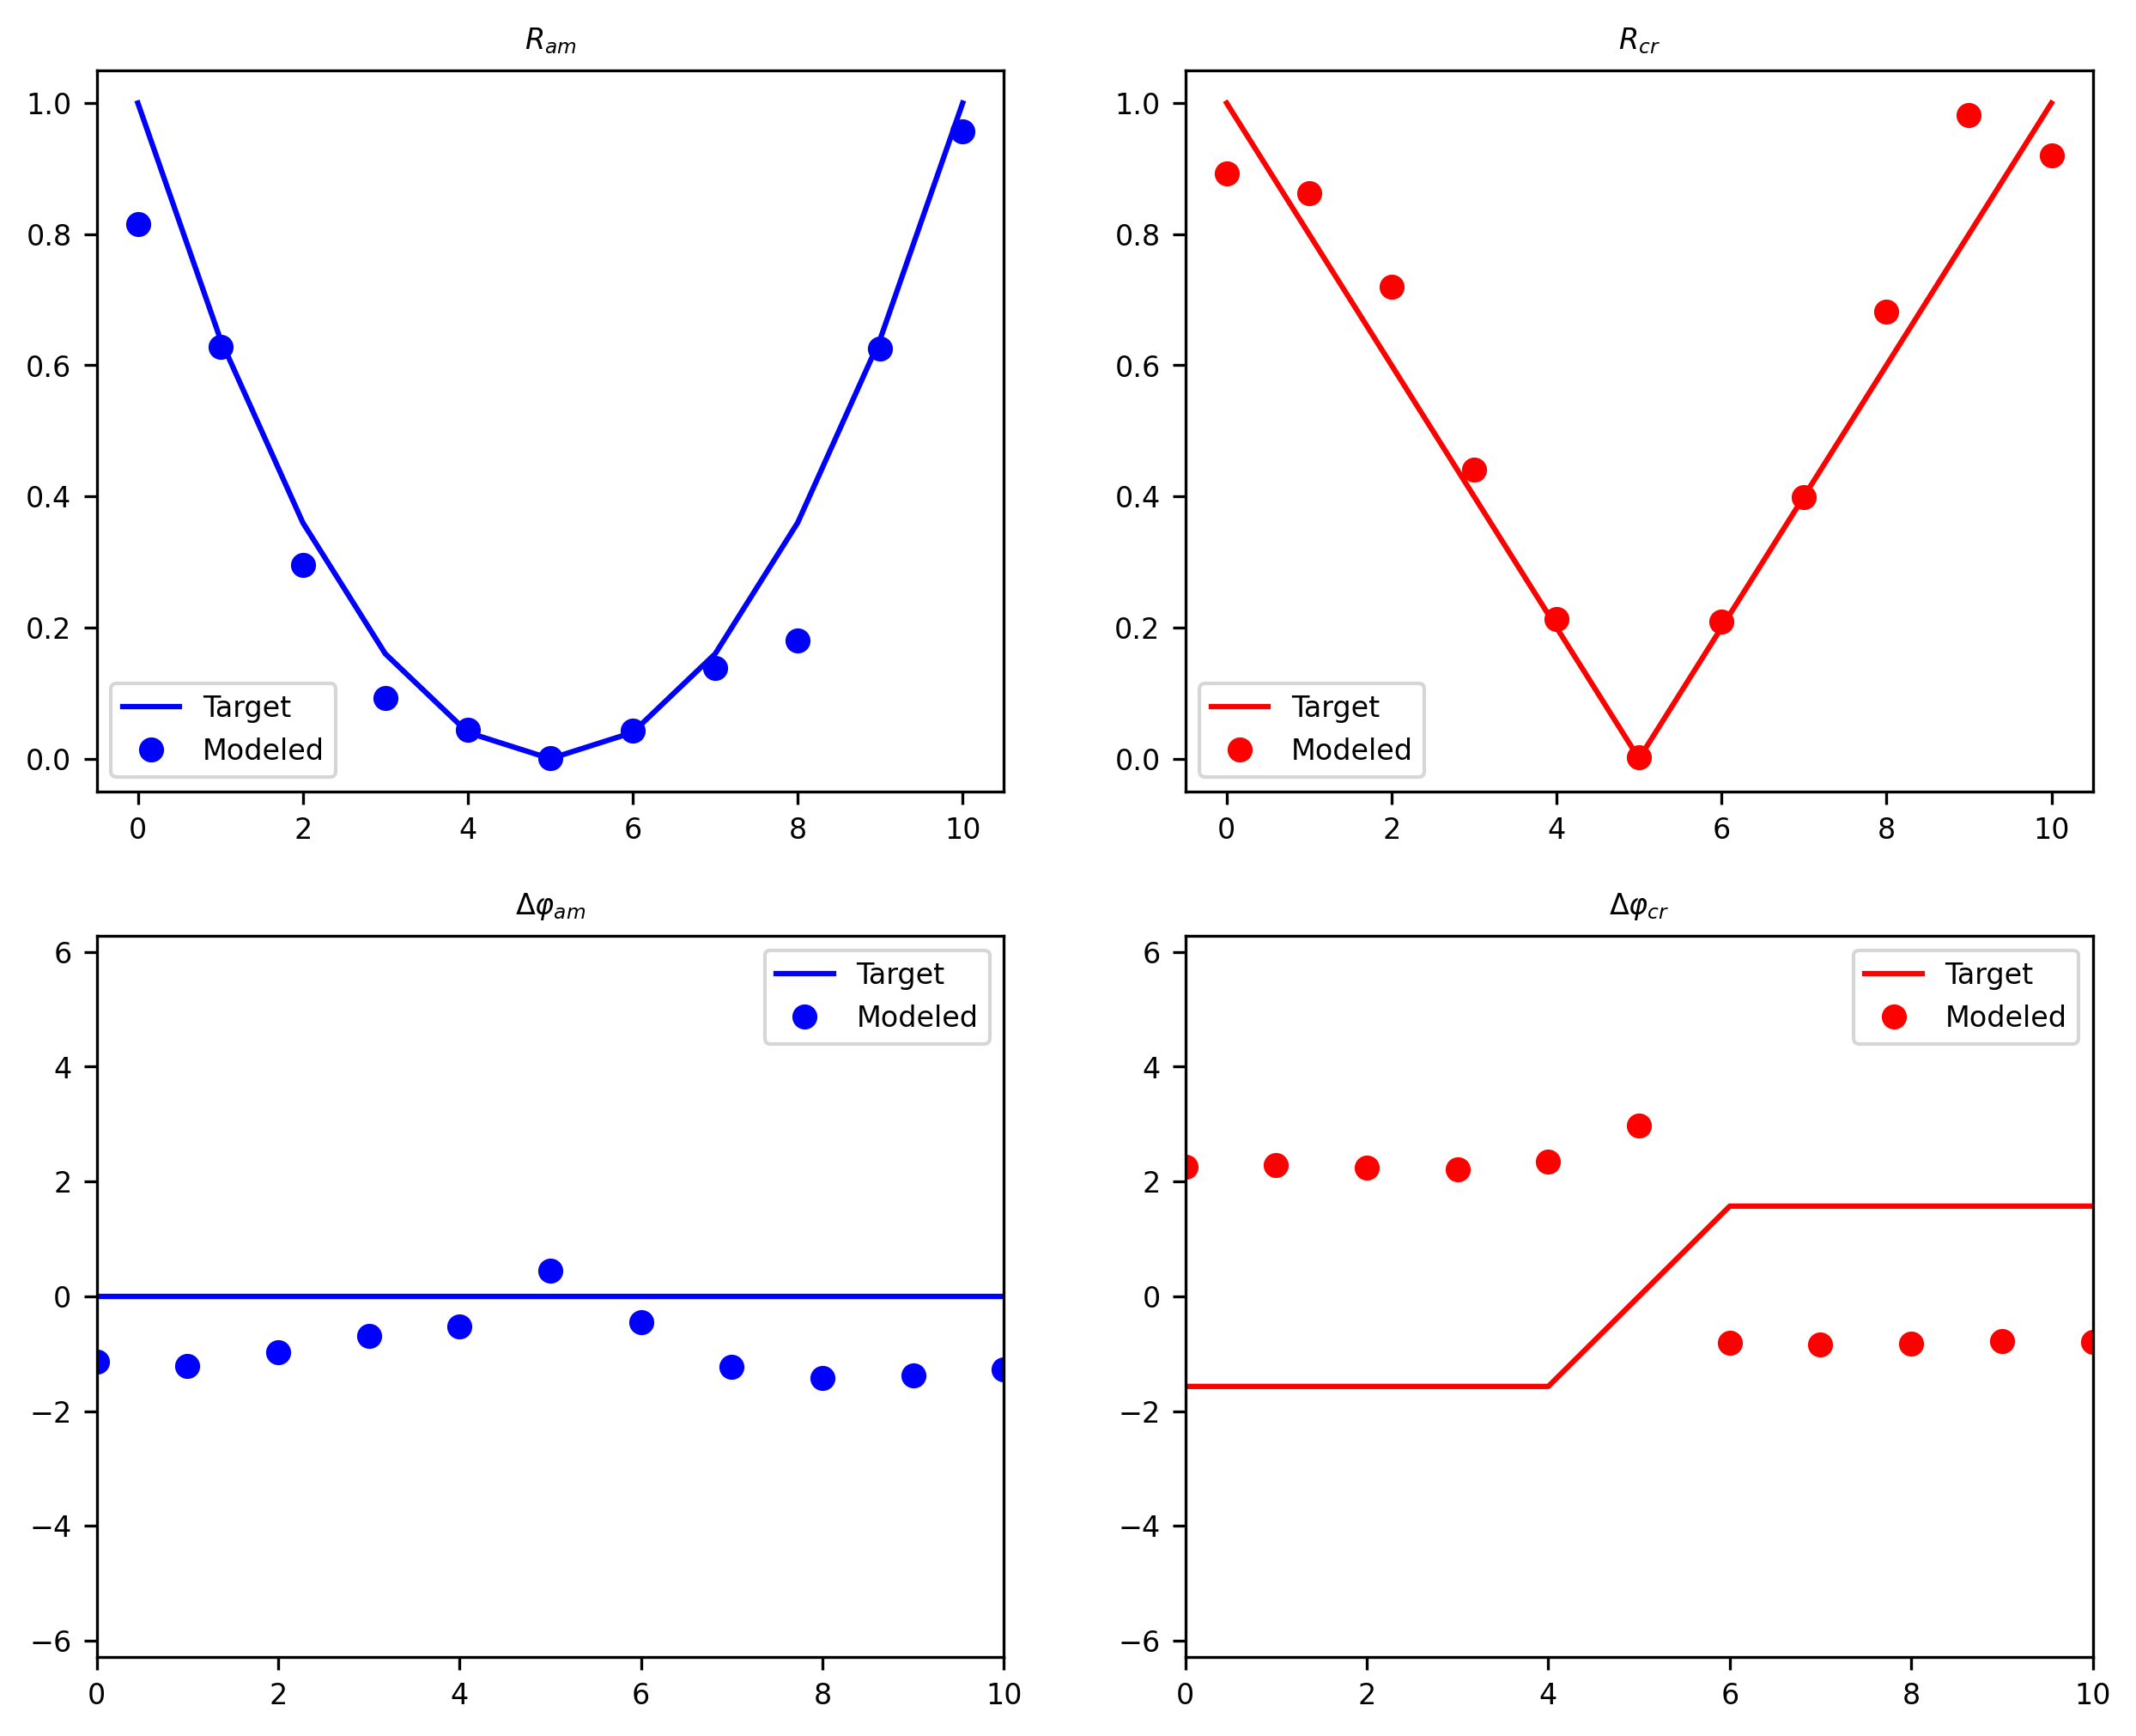

In [51]:



SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE) 
plt.rc('figure', titlesize=BIGGER_SIZE, figsize =(3, 3), dpi = 300)

# создание графика с 4 подграфиками
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# настройка заголовка
#fig.suptitle('4 графика с 2 линиями на каждом', fontsize=16)

# настройка подграфиков
axs[0, 0].plot(x, y1, "-b", label='Target')
axs[0, 0].plot(x, y2, "bo", label='Modeled')
axs[0, 0].legend()
axs[0, 0].set_title(r'$R_{am}$')

axs[0, 1].plot(x, y3, "r-", label='Target')
axs[0, 1].plot(x, y4, "ro",  label='Modeled')
axs[0, 1].legend()
axs[0, 1].set_title(r'$R_{cr}$')



#axs[0, 0].plot(x, y3, "r--",label='Target')
#axs[0, 0].plot(x, y4,"ro",  label='Modeled')
#axs[0, 0].legend()
#axs[0, 0].set_title('Пропускание с накачкой')



axs[1, 0].plot(x, y5, "b-", label='Target')
axs[1, 0].plot(x, y6, "bo", label='Modeled')
axs[1, 0].legend()
axs[1, 0].set_title(r'$\Delta\varphi_{am}$')

#axs[1, 0].plot(x, y7, "r--", label='Target')
#axs[1, 0].plot(x, y8, "ro", label='Modeled')
#axs[1, 0].legend()
#axs[1, 0].set_title('Сдвиг фазы с накачкой')


axs[1, 1].plot(x, y7, "r-", label='Target')
axs[1, 1].plot(x, y8, "ro", label='Modeled')
axs[1, 1].legend()
axs[1, 1].set_title(r'$\Delta\varphi_{cr}$')

axs[1,0].set(xlim = [0,10], ylim = [-np.pi * 2, np.pi * 2])
axs[1,1].set(xlim = [0,10], ylim = [-np.pi * 2, np.pi * 2])
#axs[1,1]
#axs[1,0]
#axs[1,0]

# отображение графика
plt.show()

SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)                                                                          # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE) 
plt.rc('figure', titlesize=BIGGER_SIZE, figsize =(7, 3), dpi = 300)


In [ ]:
import gdspy
from datetime import datetime

name = 'GDS_2025_test_24_march'



file = open(name + '.txt', 'w')
file.write("Текстовое описание одноименного файла .gds \n")
file.write("Дата создания " + str(datetime.now().date()) + "\n")
file.write("Время создания " + str(datetime.now().time()) + "\n")

file.write("Без накачки\n")
file.write("Пропускание парабола от 0 до 1? \n")
file.write("Фаза - константа \n")

file.write("С накачкой \n")
file.write("Пропускание модуль от 0 до 1? \n")
file.write("Сдвиг фазы -π/2...+π/2 \n")

file.write("a, nm\td, nm\tb, nm\tT_a\tT_c\tdphi_a\tdphi_c\tnumb\n")


l = 10*1e-6
#l = 10*1e-6

L = l * len(a)
N_pix = 1024
gdspy.current_library = gdspy.GdsLibrary()
lib = gdspy.GdsLibrary()

layer_list = [{"layer": i, "datatype": 0} for i in range(len(a))]

multipl = 10**6
num_lay=0
cell = lib.new_cell('CELL_0')
for i in range(len(a)):
    #num_lay = 0
    
    rad = d[i]/2
    per = a[i]
    b_in = b[i] / 2
    
    x0 = l * i
    y0 = 0
    
    j_col = int((l - 50*1e-9)/per)
    k_col = int((L - 50*1e-9)/per)

    #j_col = 5
    #k_col = 5
    
    disk_col = 0
    #num_lay = 0
    
    print(i)
    
    for k in range(k_col):
        for j in range(j_col):
            
            if disk_col == 200:
                disk_col = 0
                num_lay +=1
            x_center = x0 + per * j + per/2
            y_center = y0 + per * k + per/2
            layer = {"layer": num_lay, "datatype": 0} 
            #layer = {"layer": i, "datatype": 0} 
            ###cell.add(gdspy.Round((x_center * multipl, y_center * multipl), rad * multipl, tolerance=1e-3, **layer))
            cell.add(gdspy.Round((x_center * multipl, y_center * multipl), rad * multipl, inner_radius=b_in * multipl, initial_angle = - np.pi, final_angle = np.pi, tolerance=0.001, **layer))
            disk_col += 1


    A = round(a[i] * 1e9, 0)
    D = round(d[i] * 1e9, 0)
    B = round(b[i] * 1e9, 0)
    
    R_a = round(y2[i], 2)
    R_c = round(y4[i], 2)
    dphi_a = round(y6[i], 2)
    dphi_c = round(y8[i], 2)
    
    file.write(str(A) + "\t" + str(D) + "\t" + str(B) + "\t" + str(R_a) + "\t" + str(R_c) + "\t" + str(dphi_a) + "\t" + str(dphi_c) + "\t" + str(num_lay) + "\n")

            
            
            
lib.write_gds(name + '.gds')




file.close()

In [ ]:
import gdspy
from datetime import datetime

name = 'GDS_al2o3_2025_test_24_march'



file = open(name + '.txt', 'w')
file.write("Текстовое описание одноименного файла .gds \n")
file.write("Дата создания " + str(datetime.now().date()) + "\n")
file.write("Время создания " + str(datetime.now().time()) + "\n")

file.write("Без накачки\n")
file.write("Пропускание парабола от 0 до 1? \n")
file.write("Фаза - константа \n")

file.write("С накачкой \n")
file.write("Пропускание модуль от 0 до 1? \n")
file.write("Сдвиг фазы -π/2...+π/2 \n")

file.write("a, nm\td, nm\tb, nm\tT_a\tT_c\tdphi_a\tdphi_c\tnumb\n")


l = 10*1e-6
#l = 10*1e-6

L = l * len(a)
N_pix = 1024
gdspy.current_library = gdspy.GdsLibrary()
lib = gdspy.GdsLibrary()

layer_list = [{"layer": i, "datatype": 0} for i in range(len(a))]

multipl = 10**6
num_lay=0
cell = lib.new_cell('CELL_0')
for i in range(len(a)):
    #num_lay = 0
    
    rad = d[i]/2 + 100e-9
    per = a[i]
    b_in = b[i] / 2 - 100e-9
    
    x0 = l * i
    y0 = 0
    
    j_col = int((l - 50*1e-9)/per)
    k_col = int((L - 50*1e-9)/per)

    #j_col = 5
    #k_col = 5
    
    disk_col = 0
    #num_lay = 0
    
    print(i)
    
    for k in range(k_col):
        for j in range(j_col):
            
            if disk_col == 200:
                disk_col = 0
                num_lay +=1
            x_center = x0 + per * j + per/2
            y_center = y0 + per * k + per/2
            layer = {"layer": num_lay, "datatype": 0} 
            #layer = {"layer": i, "datatype": 0} 
            ###cell.add(gdspy.Round((x_center * multipl, y_center * multipl), rad * multipl, tolerance=1e-3, **layer))
            cell.add(gdspy.Round((x_center * multipl, y_center * multipl), rad * multipl, inner_radius=b_in * multipl, initial_angle = - np.pi, final_angle = np.pi, tolerance=0.001, **layer))
            disk_col += 1


    A = round(a[i] * 1e9, 0)
    D = round(d[i] * 1e9, 0)
    B = round(b[i] * 1e9, 0)
    
    R_a = round(y2[i], 2)
    R_c = round(y4[i], 2)
    dphi_a = round(y6[i], 2)
    dphi_c = round(y8[i], 2)
    
    file.write(str(A) + "\t" + str(D) + "\t" + str(B) + "\t" + str(R_a) + "\t" + str(R_c) + "\t" + str(dphi_a) + "\t" + str(dphi_c) + "\t" + str(num_lay) + "\n")

            
            
            
lib.write_gds(name + '.gds')




file.close()

In [ ]:
import gdspy
from datetime import datetime

#name = 'GDS_2024_10_14_14_14_23_PCM_Al2O3_bagel_110mum'



file = open(name + '.txt', 'w')
file.write("Текстовое описание одноименного файла .gds \n")
file.write("Дата создания " + str(datetime.now().date()) + "\n")
file.write("Время создания " + str(datetime.now().time()) + "\n")

file.write("Без накачки\n")
file.write("Пропускание парабола от 0 до 1? \n")
file.write("Фаза - константа \n")

file.write("С накачкой \n")
file.write("Пропускание модуль от 0 до 1? \n")
file.write("Сдвиг фазы -π/2...+π/2 \n")

file.write("a, nm\td, nm\tb, nm\tT_a\tT_c\tdphi_a\tdphi_c\tnumb\n")


l = 10*1e-6
#l = 10*1e-6

L = l * len(a)
N_pix = 1024
gdspy.current_library = gdspy.GdsLibrary()
lib = gdspy.GdsLibrary()

layer_list = [{"layer": i, "datatype": 0} for i in range(len(a))]

multipl = 10**6
num_lay=0
cell = lib.new_cell('CELL_0')
for i in range(len(a)):
    #num_lay = 0
    
    rad = d[i]/2 + 100e-9
    per = a[i]
    b_in = b[i] / 2 - 100e-9
    if (b_in<0):
        b_in = 0
        
    
    x0 = l * i
    y0 = 0
    
    j_col = int((l - 50*1e-9)/per)
    k_col = int((L - 50*1e-9)/per)

    #j_col = 5
    #k_col = 5
    
    disk_col = 0
    #num_lay = 0
    
    print(i)
    
    for k in range(k_col):
        for j in range(j_col):
            
            if disk_col == 200:
                disk_col = 0
                num_lay +=1
            x_center = x0 + per * j + per/2
            y_center = y0 + per * k + per/2
            layer = {"layer": num_lay, "datatype": 0} 
            #layer = {"layer": i, "datatype": 0} 
            ###cell.add(gdspy.Round((x_center * multipl, y_center * multipl), rad * multipl, tolerance=1e-3, **layer))
            cell.add(gdspy.Round((x_center * multipl, y_center * multipl), rad * multipl, inner_radius=b_in * multipl, initial_angle = - np.pi, final_angle = np.pi, tolerance=0.001, **layer))
            disk_col += 1


    A = round(a[i] * 1e9, 0)
    D = round((d[i]+ 100e-9) * 1e9, 0)
    B = round(b[i] * 1e9, 0)
    
    R_a = round(y2[i], 2)
    R_c = round(y4[i], 2)
    dphi_a = round(y6[i], 2)
    dphi_c = round(y8[i], 2)
    
    file.write(str(A) + "\t" + str(D) + "\t" + str(B) + "\t" + str(R_a) + "\t" + str(R_c) + "\t" + str(dphi_a) + "\t" + str(dphi_c) + "\t" + str(num_lay) + "\n")

            
            
            
lib.write_gds(name + '.gds')




file.close()